# Comprehensive Layer Importance Method Benchmark

Compares **all** layer-ranking methods across **five target bit-widths** (INT8, INT4, INT3, INT2, INT1) for two architectures: ResNet-18 and ViT-Small on CIFAR-10.

## Protocol
For each bit-width *B* ∈ {1, 2, 3, 4, 8}:
1. **Baseline**: all layers quantized to *B*-bit (per-channel symmetric).
2. **Recovery sweep**: select top-*k* layers by each method's score → upgrade those layers to INT8, keep the rest at *B*-bit.
3. **Recovery** = accuracy(mixed) − accuracy(all-*B*-bit baseline).
4. **Memory savings** = bits saved vs FP32 = 1 − (k·8 + (L−k)·B) / (L·32).

## Methods
| Group | Method | Description | Data? |
|-------|--------|-------------|-------|
| Yours | **PCT** | Per-channel truncation error | ✗ |
| Yours | **SEA** | Spectral energy asymmetry (1/SVD-entropy) | ✗ |
| Yours | **NSDS** | Kurtosis × effective-rank | ✗ |
| Baseline | **OLD** | Max-scale outlier dimension | ✗ |
| Baseline | **Entropy** | Weight histogram entropy | ✗ |
| Baseline | **Random** | Random ranking (3-seed average) | ✗ |
| Established | **HAWQ** | Hessian top-eigenvalue trace (power iter) | 512 imgs |
| Established | **InfoQ** | Cosine-distance after per-layer quant-drop | 512 imgs |
| Established | **BMPQ** | Fisher \|G\|·\|W\| proxy | 512 imgs |
| Established | **CLADO** | Layer-wise AD-loss + pairwise synergy | 512 imgs |

In [1]:
!pip install scipy scikit-learn -q


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
from __future__ import annotations

import copy
import math
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from IPython.display import display
from scipy.stats import spearmanr
from torch.utils.data import DataLoader
from torchvision import datasets

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 130, 'font.size': 9})

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT = Path('.').resolve()
DATA_ROOT = ROOT / 'data'
OUT_DIR   = ROOT / 'results' / 'comprehensive_layer_importance_benchmark'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_RESNET_CANDIDATES = [
    ROOT / 'checkpoints_backdoor_resnet18',
    ROOT / 'checkpoints_resnet_cifar10',
]
CKPT_RESNET = next((p for p in CKPT_RESNET_CANDIDATES if p.exists()),
                   CKPT_RESNET_CANDIDATES[0])
CKPT_VIT = ROOT / 'checkpoints_vit_cifar10' / 'vit_small_0.pt'

# ── Hyper-params ───────────────────────────────────────────────────────────────
MODEL_ID      = 0
BATCH_SIZE    = 128
NUM_WORKERS   = 0
RANDOM_SEED   = 42
CALIB_IMAGES  = 512
TOPK_LIST     = [1, 3, 5, 10, 20]   # k values for 'upgrade top-k layers'
BASELINE_BITS = [1, 2, 3, 4, 8]     # 'low' bit-width scenarios
PROTECT_BITS  = 8                   # layers ranked important get this many bits
HAWQ_POWER_STEPS = 3
CLADO_PAIRS      = 20

# ── Controls ───────────────────────────────────────────────────────────────────
RUN_RESNET = True
RUN_VIT    = True
# Set False to skip expensive calibration-data methods (HAWQ/InfoQ/BMPQ/CLADO)
RUN_DATA_REQ = True
FORCE_RECOMPUTE = False   # if True ignores cached CSVs

# ── Device ─────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2471, 0.2435, 0.2616)
EVAL_TRANSFORM = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

print(f'Device : {DEVICE}')
print(f'Out dir: {OUT_DIR}')

Device : mps
Out dir: /Users/nathan/Documents/bruh4/results/comprehensive_layer_importance_benchmark


In [3]:
# ── ResNet-18 (CIFAR-10 variant) ───────────────────────────────────────────────
RN_LAYER_NAMES = [
    'conv1',
    'layer1.0.conv1', 'layer1.0.conv2', 'layer1.1.conv1', 'layer1.1.conv2',
    'layer2.0.conv1', 'layer2.0.conv2', 'layer2.0.downsample.0',
    'layer2.1.conv1', 'layer2.1.conv2',
    'layer3.0.conv1', 'layer3.0.conv2', 'layer3.0.downsample.0',
    'layer3.1.conv1', 'layer3.1.conv2',
    'layer4.0.conv1', 'layer4.0.conv2', 'layer4.0.downsample.0',
    'layer4.1.conv1', 'layer4.1.conv2', 'fc',
]

def rn_get_module(model, name):
    m = model
    for p in name.split('.'):
        m = getattr(m, p)
    return m

def get_resnet18_cifar(num_classes=10):
    m = torchvision.models.resnet18(weights=None, num_classes=num_classes)
    m.conv1  = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    return m

def load_resnet(path: Path) -> nn.Module:
    ckpt = torch.load(path, map_location='cpu', weights_only=False)
    sd = ckpt['state_dict'] if isinstance(ckpt, dict) and 'state_dict' in ckpt else ckpt
    sd = {k: v for k, v in sd.items()
          if 'quantizer' not in k and 'range_tracker' not in k}
    m = get_resnet18_cifar()
    m.load_state_dict(sd, strict=False)
    return m.eval().cpu()

# ── ViT-Small (custom CIFAR-10 variant) ───────────────────────────────────────
class ViTPatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, embed_dim=256):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, embed_dim, patch_size, patch_size)
        n = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n + 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
    def forward(self, x):
        b = x.shape[0]
        x = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(b, -1, -1)
        return torch.cat([cls, x], dim=1) + self.pos_embed

class ViTSelfAttn(nn.Module):
    def __init__(self, dim=256, heads=8):
        super().__init__()
        self.heads = heads; self.dh = dim // heads
        self.scale = self.dh ** -0.5
        self.q  = nn.Linear(dim, dim, bias=False)
        self.k  = nn.Linear(dim, dim, bias=False)
        self.v  = nn.Linear(dim, dim, bias=False)
        self.out = nn.Linear(dim, dim, bias=False)
    def forward(self, x):
        b, n, d = x.shape; h, dh = self.heads, self.dh
        q = self.q(x).reshape(b,n,h,dh).transpose(1,2)
        k = self.k(x).reshape(b,n,h,dh).transpose(1,2)
        v = self.v(x).reshape(b,n,h,dh).transpose(1,2)
        a = (q @ k.transpose(-2,-1)) * self.scale
        o = (a.softmax(-1) @ v).transpose(1,2).reshape(b,n,d)
        return self.out(o)

class ViTBlock(nn.Module):
    def __init__(self, dim=256, heads=8, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim); self.attn = ViTSelfAttn(dim, heads)
        self.norm2 = nn.LayerNorm(dim)
        md = int(dim * mlp_ratio)
        self.fc1 = nn.Linear(dim, md); self.fc2 = nn.Linear(md, dim)
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return x + self.fc2(F.gelu(self.fc1(self.norm2(x))))

class ViTSmall(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.patch_embed = ViTPatchEmbed()
        self.blocks = nn.Sequential(*[ViTBlock() for _ in range(6)])
        self.norm = nn.LayerNorm(256)
        self.head = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.patch_embed(x)
        x = self.blocks(x)
        return self.head(self.norm(x[:, 0]))

VIT_LAYER_NAMES = (
    ['patch_embed.proj'] +
    [f'blocks.{b}.attn.{p}' for b in range(6) for p in ('q','k','v','out')] +
    [f'blocks.{b}.{p}'      for b in range(6) for p in ('fc1','fc2')]
)

def vit_get_module(model, name):
    m = model
    for p in name.split('.'):
        m = getattr(m, p)
    return m

def load_vit(path: Path) -> nn.Module:
    m = ViTSmall()
    sd = torch.load(path, map_location='cpu', weights_only=False)
    if isinstance(sd, dict) and 'state_dict' in sd:
        sd = sd['state_dict']
    m.load_state_dict(sd, strict=False)
    return m.eval().cpu()

print('Model definitions ready.')

Model definitions ready.


In [4]:
# ── Data loaders ──────────────────────────────────────────────────────────────
def cifar10_test_loader(max_images=None):
    ds = datasets.CIFAR10(str(DATA_ROOT), train=False, download=True,
                          transform=EVAL_TRANSFORM)
    if max_images:
        ds = torch.utils.data.Subset(ds, range(min(max_images, len(ds))))
    return DataLoader(ds, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

def cifar10_calib_loader(n=CALIB_IMAGES):
    ds = datasets.CIFAR10(str(DATA_ROOT), train=True, download=True,
                          transform=EVAL_TRANSFORM)
    ds = torch.utils.data.Subset(ds, range(min(n, len(ds))))
    return DataLoader(ds, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

test_loader  = cifar10_test_loader()
calib_loader = cifar10_calib_loader()
print(f'Test  batches: {len(test_loader)}')
print(f'Calib batches: {len(calib_loader)}')

Test  batches: 79
Calib batches: 4


In [5]:
# ── Quantization helpers ───────────────────────────────────────────────────────

def per_channel_scale(w2d: torch.Tensor, bits: int, clip: float = 3.3) -> torch.Tensor:
    """Per-output-channel quantization scale."""
    qmax = 2 ** (bits - 1) - 1
    if bits == 1:
        return w2d.abs().max(dim=1, keepdim=True).values.clamp(min=1e-12)
    if w2d.shape[1] == 1:
        return (w2d.abs() / qmax).clamp(min=1e-12)
    sigma = w2d.std(dim=1, keepdim=True)
    s = (clip * sigma / qmax).clamp(min=1e-12)
    bad = torch.isnan(s) | (s <= 0)
    if bad.any():
        fb = (w2d.abs().max(dim=1, keepdim=True).values / qmax).clamp(min=1e-12)
        s = torch.where(bad, fb, s)
    return s


def quantize_weights(w: torch.Tensor, bits: int, clip: float = 3.3) -> torch.Tensor:
    """Quantize a weight tensor in-place style, return dequantized copy."""
    qmax = 2 ** (bits - 1) - 1
    w2d  = w.float().reshape(w.shape[0], -1)
    s    = per_channel_scale(w2d, bits, clip)
    q    = (w2d / s).round().clamp(-qmax, qmax)
    return (q * s).reshape(w.shape)


def quantize_model(
    model: nn.Module,
    layer_names: list[str],
    get_module,
    high_layers: set[str],
    bits_high: int = 8,
    bits_low: int  = 4,
) -> nn.Module:
    """Deep-copy model; quantize each layer to bits_high or bits_low."""
    m = copy.deepcopy(model).cpu()
    with torch.no_grad():
        for name in layer_names:
            bits = bits_high if name in high_layers else bits_low
            mod  = get_module(m, name)
            mod.weight.data = quantize_weights(mod.weight.data, bits).to(mod.weight.dtype)
    return m.eval()


def param_count(model: nn.Module, layer_names: list, get_module) -> dict[str, int]:
    return {n: get_module(model, n).weight.numel() for n in layer_names}


def memory_savings(
    layer_names: list[str],
    param_counts: dict[str, int],
    high_layers: set[str],
    bits_high: int,
    bits_low: int,
) -> dict:
    """Return dict with avg_bits, memory_vs_fp32, memory_vs_int8."""
    total = sum(param_counts[n] for n in layer_names)
    used  = sum(
        param_counts[n] * (bits_high if n in high_layers else bits_low)
        for n in layer_names
    )
    avg_bits = used / max(total, 1)
    return {
        'avg_bits'       : avg_bits,
        'saving_vs_fp32' : 1.0 - avg_bits / 32.0,
        'saving_vs_int8' : 1.0 - avg_bits / 8.0,
    }


print('Quantization helpers ready.')

Quantization helpers ready.


In [6]:
# ── Evaluation helpers ─────────────────────────────────────────────────────────

@torch.no_grad()
def eval_accuracy(model: nn.Module, loader) -> float:
    m = copy.deepcopy(model).to(DEVICE).eval()
    c = t = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        p = m(x).argmax(1)
        c += (p == y).sum().item(); t += y.numel()
    return float(c / max(t, 1))


@torch.no_grad()
def collect_probs(model: nn.Module, loader):
    m = copy.deepcopy(model).to(DEVICE).eval()
    ps, ys = [], []
    for x, y in loader:
        ps.append(torch.softmax(m(x.to(DEVICE)), 1).cpu())
        ys.append(y)
    return torch.cat(ps), torch.cat(ys)


def _bin_ece(conf, corr, n_bins=15):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = mce = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        m = (conf >= lo) & (conf < hi) if i < n_bins-1 else (conf >= lo) & (conf <= hi)
        if not m.any(): continue
        g = abs(corr[m].mean() - conf[m].mean())
        ece += m.mean() * g; mce = max(mce, g)
    return float(ece), float(mce)


def calibration_metrics(probs: torch.Tensor, labels: torch.Tensor) -> dict:
    probs  = probs.float().cpu(); labels = labels.cpu().long()
    conf, pred = probs.max(dim=1)
    corr   = (pred == labels).numpy().astype(np.float64)
    ece, mce = _bin_ece(conf.numpy(), corr)
    nll    = float(F.nll_loss(torch.log(probs.clamp(min=1e-12)), labels).item())
    oh     = F.one_hot(labels, num_classes=probs.shape[1]).float()
    brier  = float(((oh - probs)**2).sum(dim=1).mean().item())
    return {'accuracy': float(corr.mean()), 'ece': ece, 'mce': mce,
            'nll': nll, 'brier': brier}


print('Eval helpers ready.')

Eval helpers ready.


In [7]:
# ── Data-free scoring functions ────────────────────────────────────────────────

def _svdvals_cpu(w2d: torch.Tensor) -> torch.Tensor:
    """svdvals on CPU (MPS does not support it)."""
    return torch.linalg.svdvals(w2d.detach().float().cpu())


def pct_score(weight: torch.Tensor, bits: int = 8) -> tuple[float, float]:
    """Returns (pct_rel_error, old_rel_error).
    PCT: per-channel truncation error / weight norm.
    OLD: outlier-dimension (abs-max scale) error / weight norm.
    """
    qmax = 2 ** (bits - 1) - 1
    w = weight.float().reshape(weight.shape[0], -1)
    # PCT (per-channel)
    s_pct   = per_channel_scale(w, bits)
    wq_pct  = (w / s_pct).round().clamp(-qmax, qmax) * s_pct
    pct_err = float((w - wq_pct).norm('fro') / max(w.norm('fro').item(), 1e-12))
    # OLD (global abs-max scale)
    s_old  = (w.abs().max() / qmax).clamp(min=1e-12)
    wq_old = (w / s_old).round().clamp(-qmax, qmax) * s_old
    old_err = float((w - wq_old).norm('fro') / max(w.norm('fro').item(), 1e-12))
    return pct_err, old_err


def entropy_score(weight: torch.Tensor, n_bins: int = 256) -> float:
    w = weight.detach().float().reshape(-1).cpu().numpy()
    cnt, _ = np.histogram(w, bins=n_bins)
    p = cnt.astype(np.float64) / max(cnt.sum(), 1)
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())


def sea_score(weight: torch.Tensor, eps: float = 1e-8) -> float:
    """Spectral Energy Asymmetry: inverse of SVD-based entropy (1 = concentrated)."""
    w = weight.detach().float().reshape(weight.shape[0], -1)
    try:
        S = _svdvals_cpu(w)
    except Exception:
        return 0.0
    S2 = S.pow(2)
    p  = (S2 / S2.sum().clamp(min=eps)).clamp(min=1e-12)
    return 1.0 / max(float(-(p * p.log()).sum()), eps)


def excess_kurtosis(w: torch.Tensor) -> float:
    x = w.reshape(-1).float()
    mu = x.mean(); sig2 = x.var(unbiased=False)
    if sig2 < 1e-12: return 0.0
    return float((((x - mu)**4).mean() / (sig2**2) - 3.0).item())


def effective_rank(weight: torch.Tensor) -> float:
    w2d = weight.float().reshape(weight.shape[0], -1)
    s   = _svdvals_cpu(w2d)
    if s.sum() < 1e-12: return 1.0
    p = (s / s.sum()).clamp(min=1e-12)
    return float(torch.exp(-(p * p.log()).sum()).item())


def compute_cheap_scores(
    model: nn.Module,
    layer_names: list[str],
    get_module,
) -> pd.DataFrame:
    rows = []
    for n in layer_names:
        w = get_module(model, n).weight
        pct, old = pct_score(w)
        rows.append({
            'layer_name'   : n,
            'score_pct'    : pct,
            'score_old'    : old,
            'score_entropy': entropy_score(w),
            'score_sea'    : sea_score(w),
            'score_nsds'   : excess_kurtosis(w) * effective_rank(w),
        })
    return pd.DataFrame(rows)


def random_score(layer_names: list[str], seed: int = RANDOM_SEED) -> dict:
    """Average over 3 random seeds to reduce variance."""
    rng = np.random.default_rng(seed)
    vals = np.zeros(len(layer_names))
    for s in range(3):
        perm = rng.permutation(len(layer_names)).astype(float)
        vals += perm
    return dict(zip(layer_names, vals / 3))


print('Data-free scoring functions ready.')

Data-free scoring functions ready.


In [8]:
# ── Data-required scoring functions (HAWQ / InfoQ / BMPQ / CLADO) ─────────────

def _one_batch(loader):
    return next(iter(loader))


def hawq_scores(
    model: nn.Module,
    layer_names: list[str],
    get_module,
    calib_loader,
    power_steps: int = HAWQ_POWER_STEPS,
) -> dict:
    """HAWQ: approximate top-eigenvalue of per-layer Hessian via power iteration.
    Ref: Dong et al., HAWQ 2019 (arXiv:1905.03696).
    """
    x, y = _one_batch(calib_loader)
    x, y = x.to(DEVICE), y.to(DEVICE)
    m = copy.deepcopy(model).to(DEVICE).train()
    out = {}
    for n in layer_names:
        w = get_module(m, n).weight
        v = torch.randn_like(w); v /= (v.norm() + 1e-12)
        for _ in range(power_steps):
            for p in m.parameters(): p.grad = None
            loss = F.cross_entropy(m(x), y)
            g    = torch.autograd.grad(loss, w, create_graph=True)[0]
            hv   = torch.autograd.grad((g * v).sum(), w, retain_graph=True)[0]
            v    = hv / (hv.norm() + 1e-12)
        for p in m.parameters(): p.grad = None
        loss = F.cross_entropy(m(x), y)
        g    = torch.autograd.grad(loss, w, create_graph=True)[0]
        hv   = torch.autograd.grad((g * v).sum(), w)[0]
        out[n] = float((v * hv).sum().abs().item())
    return out


def infoq_scores(
    model: nn.Module,
    layer_names: list[str],
    get_module,
    calib_loader,
) -> dict:
    """InfoQ: output-space cosine disruption when one layer is dropped to low-bit.
    Ref: inspired by layer sensitivity analysis in EBS / InfoQ literature.
    """
    x, _ = _one_batch(calib_loader)
    x = x.to(DEVICE)
    base = copy.deepcopy(model).to(DEVICE).eval()
    with torch.no_grad():
        y0 = base(x)
    scores = {}
    for n in layer_names:
        # All layers INT8 except n which drops to INT4 — how much does output shift?
        mq = quantize_model(model, layer_names, get_module,
                            high_layers=set(layer_names) - {n},
                            bits_high=8, bits_low=4)
        mq = mq.to(DEVICE).eval()
        with torch.no_grad():
            yq  = mq(x)
            cos = F.cosine_similarity(y0.flatten(1), yq.flatten(1), dim=1).mean().item()
        scores[n] = 1.0 - cos
    return scores


def bmpq_scores(
    model: nn.Module,
    layer_names: list[str],
    get_module,
    calib_loader,
) -> dict:
    """BMPQ: Fisher-weighted magnitude proxy |G|·|W|.
    Ref: approximation of Fisher information used in EBS / bit-allocation literature.
    """
    x, y = _one_batch(calib_loader)
    x, y = x.to(DEVICE), y.to(DEVICE)
    m = copy.deepcopy(model).to(DEVICE).train()
    for p in m.parameters(): p.grad = None
    F.cross_entropy(m(x), y).backward()
    out = {}
    for n in layer_names:
        w = get_module(m, n).weight
        g = torch.zeros_like(w) if w.grad is None else w.grad
        out[n] = float((g.abs() * w.abs()).mean().item())
    return out


def clado_scores(
    model: nn.Module,
    layer_names: list[str],
    get_module,
    calib_loader,
    sample_pairs: int = CLADO_PAIRS,
) -> dict:
    """CLADO: per-layer AD-loss increase + pairwise synergy correction.
    Ref: layer-wise anomaly-detection loss used in CLADO (calibration-aware quant).
    """
    x, y = _one_batch(calib_loader)
    x, y = x.to(DEVICE), y.to(DEVICE)
    base = copy.deepcopy(model).to(DEVICE).eval()
    with torch.no_grad():
        l0 = F.cross_entropy(base(x), y).item()

    # Single-layer contribution
    single = {}
    for n in layer_names:
        mq = quantize_model(model, layer_names, get_module,
                            high_layers=set(layer_names) - {n},
                            bits_high=8, bits_low=4).to(DEVICE).eval()
        with torch.no_grad():
            single[n] = F.cross_entropy(mq(x), y).item() - l0

    # Pairwise synergy
    rng = np.random.default_rng(RANDOM_SEED)
    pairs = [tuple(rng.choice(layer_names, size=2, replace=False))
             for _ in range(min(sample_pairs, max(1, len(layer_names) // 2)))]
    pair_gain = defaultdict(float); pair_cnt = defaultdict(int)
    for a, b in pairs:
        mq = quantize_model(model, layer_names, get_module,
                            high_layers=set(layer_names) - {a, b},
                            bits_high=8, bits_low=4).to(DEVICE).eval()
        with torch.no_grad():
            lij = F.cross_entropy(mq(x), y).item() - l0
        syn = abs(lij - (single[a] + single[b]))
        pair_gain[a] += syn; pair_gain[b] += syn
        pair_cnt[a] += 1;  pair_cnt[b] += 1

    return {n: float(single[n] + pair_gain[n] / max(pair_cnt[n], 1))
            for n in layer_names}


print('Data-required scoring functions ready.')

Data-required scoring functions ready.


In [9]:
# ── Score all models (with caching) ───────────────────────────────────────────

SCORE_COLS = ['score_pct', 'score_old', 'score_entropy', 'score_sea',
              'score_nsds', 'score_hawq', 'score_infoq', 'score_bmpq', 'score_clado']

ALL_METHODS = ['pct', 'old', 'entropy', 'sea', 'nsds',
               'hawq', 'infoq', 'bmpq', 'clado', 'random']

METHOD_TO_COL = {
    'pct'    : 'score_pct',
    'old'    : 'score_old',
    'entropy': 'score_entropy',
    'sea'    : 'score_sea',
    'nsds'   : 'score_nsds',
    'hawq'   : 'score_hawq',
    'infoq'  : 'score_infoq',
    'bmpq'   : 'score_bmpq',
    'clado'  : 'score_clado',
    'random' : 'score_random',
}

METHOD_STYLE = {
    # Yours (data-free)
    'pct'    : dict(color='#e6194b', linestyle='-',  marker='o', label='PCT (yours)'),
    'sea'    : dict(color='#f58231', linestyle='-',  marker='s', label='SEA (yours)'),
    'nsds'   : dict(color='#ffe119', linestyle='-',  marker='^', label='NSDS (yours)'),
    # Weight-only baselines
    'old'    : dict(color='#3cb44b', linestyle='--', marker='D', label='OLD'),
    'entropy': dict(color='#4363d8', linestyle='--', marker='v', label='Entropy'),
    'random' : dict(color='#a9a9a9', linestyle=':',  marker='x', label='Random'),
    # Established (data-required)
    'hawq'   : dict(color='#911eb4', linestyle='-.', marker='P', label='HAWQ'),
    'infoq'  : dict(color='#42d4f4', linestyle='-.', marker='*', label='InfoQ'),
    'bmpq'   : dict(color='#f032e6', linestyle='-.', marker='h', label='BMPQ'),
    'clado'  : dict(color='#469990', linestyle='-.', marker='<', label='CLADO'),
}


def build_all_scores(
    model: nn.Module,
    layer_names: list[str],
    get_module,
    calib_loader,
    cache_path: Path,
) -> pd.DataFrame:
    if cache_path.exists() and not FORCE_RECOMPUTE:
        df = pd.read_csv(cache_path)
        print(f'  Loaded from cache: {cache_path.name}')
        return df

    print('  Computing cheap (data-free) scores...')
    df = compute_cheap_scores(model, layer_names, get_module)
    df['score_random'] = df['layer_name'].map(random_score(layer_names))

    if RUN_DATA_REQ:
        print('  Computing BMPQ scores...')
        df['score_bmpq'] = df['layer_name'].map(
            bmpq_scores(model, layer_names, get_module, calib_loader))

        print('  Computing InfoQ scores (one forward per layer)...')
        df['score_infoq'] = df['layer_name'].map(
            infoq_scores(model, layer_names, get_module, calib_loader))

        print('  Computing CLADO scores (one quant-fwd per layer + pair syns)...')
        df['score_clado'] = df['layer_name'].map(
            clado_scores(model, layer_names, get_module, calib_loader))

        print('  Computing HAWQ scores (Hessian power iteration)...')
        df['score_hawq'] = df['layer_name'].map(
            hawq_scores(model, layer_names, get_module, calib_loader))
    else:
        for c in ['score_hawq', 'score_infoq', 'score_bmpq', 'score_clado']:
            df[c] = float('nan')

    df.to_csv(cache_path, index=False)
    print(f'  Saved scores → {cache_path.name}')
    return df


print('Score runner defined.')
print('Will run scores for:', ['ResNet'] * RUN_RESNET + ['ViT'] * RUN_VIT)

Score runner defined.
Will run scores for: ['ResNet', 'ViT']


In [10]:
# ── ResNet-18 scores ──────────────────────────────────────────────────────────
if RUN_RESNET:
    rn_path = CKPT_RESNET / f'clean_{MODEL_ID}.pt'
    if not rn_path.exists():
        raise FileNotFoundError(rn_path)
    m_rn = load_resnet(rn_path)
    print(f'ResNet-18 loaded from {rn_path.name}')

    rn_score_cache = OUT_DIR / 'resnet_scores.csv'
    print('Computing ResNet scores...')
    rn_df = build_all_scores(m_rn, RN_LAYER_NAMES, rn_get_module,
                              calib_loader, rn_score_cache)
    rn_params = param_count(m_rn, RN_LAYER_NAMES, rn_get_module)
    display(rn_df.set_index('layer_name').round(5))
else:
    print('ResNet skipped (RUN_RESNET=False)')

ResNet-18 loaded from clean_0.pt
Computing ResNet scores...
  Computing cheap (data-free) scores...
  Computing BMPQ scores...
  Computing InfoQ scores (one forward per layer)...
  Computing CLADO scores (one quant-fwd per layer + pair syns)...
  Computing HAWQ scores (Hessian power iteration)...
  Saved scores → resnet_scores.csv


,score_pct,score_old,score_entropy,score_sea,score_nsds,score_random,score_bmpq,score_infoq,score_clado,score_hawq
layer_name,,,,,,,,,,
conv1,0.02000,0.01911,3.84711,0.47801,178.52424,12.66667,0.00034,0.07304,0.14555,0.50836
layer1.0.conv1,0.21953,0.06997,2.69113,0.34705,3023.18423,12.00000,0.00001,0.07632,0.31959,1.58760
layer1.0.conv2,0.22464,0.04096,3.21252,0.30996,1354.20448,13.00000,0.00001,0.07898,0.17196,1.30321
layer1.1.conv1,0.20218,0.06343,2.84458,0.32432,2380.04805,18.66667,0.00001,0.07541,0.32098,1.23921
layer1.1.conv2,0.15140,0.03504,3.51042,0.31178,776.78562,6.66667,0.00001,0.07843,0.16597,1.11183
layer2.0.conv1,0.19345,0.04162,3.12815,0.27043,1891.11283,11.66667,0.00001,0.08472,0.19005,2.38900
layer2.0.conv2,0.10547,0.03248,3.68307,0.24663,719.66930,6.33333,0.00001,0.07748,0.16785,1.68533
layer2.0.downsample.0,0.08098,0.02688,3.90932,0.32105,304.98545,9.66667,0.00005,0.07854,0.33257,0.98478
layer2.1.conv1,0.05789,0.02555,3.82146,0.24952,546.98174,8.00000,0.00001,0.07774,0.32594,2.04236


In [11]:
# ── ViT-Small scores ──────────────────────────────────────────────────────────
if RUN_VIT:
    if not CKPT_VIT.exists():
        raise FileNotFoundError(CKPT_VIT)
    m_vit = load_vit(CKPT_VIT)
    print(f'ViT-Small loaded from {CKPT_VIT.name}')

    vit_score_cache = OUT_DIR / 'vit_scores.csv'
    print('Computing ViT scores...')
    vit_df = build_all_scores(m_vit, VIT_LAYER_NAMES, vit_get_module,
                               calib_loader, vit_score_cache)
    vit_params = param_count(m_vit, VIT_LAYER_NAMES, vit_get_module)
    display(vit_df.set_index('layer_name').round(5))
else:
    print('ViT skipped (RUN_VIT=False)')

ViT-Small loaded from vit_small_0.pt
Computing ViT scores...
  Computing cheap (data-free) scores...
  Computing BMPQ scores...
  Computing InfoQ scores (one forward per layer)...
  Computing CLADO scores (one quant-fwd per layer + pair syns)...
  Computing HAWQ scores (Hessian power iteration)...
  Saved scores → vit_scores.csv


,score_pct,score_old,score_entropy,score_sea,score_nsds,score_random,score_bmpq,score_infoq,score_clado,score_hawq
layer_name,,,,,,,,,,
patch_embed.proj,0.00756,0.00564,5.30405,0.26919,-46.96543,27.00000,0.00011,0.00686,0.00141,22.26038
blocks.0.attn.q,0.00789,0.01018,4.83604,0.21824,-65.20650,28.33333,0.00000,0.00006,-0.00001,0.09741
blocks.0.attn.k,0.00838,0.00971,4.83075,0.21636,-57.10183,19.00000,0.00000,0.00006,0.00002,0.17136
blocks.0.attn.v,0.00768,0.00880,4.90780,0.20483,-120.75733,18.33333,0.00000,0.00017,0.00008,2.20379
blocks.0.attn.out,0.00935,0.00937,4.85982,0.20571,-63.18101,5.33333,0.00000,0.00014,0.00013,1.28075
blocks.1.attn.q,0.00860,0.00962,4.86149,0.21607,-55.87598,18.66667,0.00000,0.00008,-0.00003,0.76311
blocks.1.attn.k,0.00842,0.00937,4.87033,0.21537,-62.15701,29.33333,0.00000,0.00009,-0.00001,0.79392
blocks.1.attn.v,0.00865,0.00982,4.88410,0.21478,-59.72985,11.66667,0.00001,0.00021,0.00039,3.20077
blocks.1.attn.out,0.00798,0.00905,4.89462,0.20864,-68.78318,17.00000,0.00001,0.00026,-0.00003,2.17206


In [12]:
# ── Main experiment: accuracy recovery + calibration sweep ─────────────────────

def get_active_methods(score_df: pd.DataFrame) -> list[str]:
    active = []
    for m in ALL_METHODS:
        col = METHOD_TO_COL[m]
        if col in score_df.columns and not score_df[col].isna().all():
            active.append(m)
    return active


def top_k_layers(
    score_df: pd.DataFrame,
    method: str,
    k: int,
    layer_names: list[str],
    seed: int = RANDOM_SEED,
) -> set[str]:
    """Return the k layer names with the highest score for `method`."""
    if method == 'random':
        rng = np.random.default_rng(seed)
        return set(rng.choice(layer_names, size=min(k, len(layer_names)), replace=False).tolist())
    col = METHOD_TO_COL[method]
    ranked = score_df.sort_values(col, ascending=False)['layer_name'].tolist()
    return set(ranked[:k])


def missing_baseline_bits(df: pd.DataFrame, bits_list: list[int] | None = None) -> list[int]:
    bits_list = bits_list or BASELINE_BITS
    present = set(
        df.loc[df['method'].astype(str).str.startswith('baseline_int'), 'bits_low']
        .dropna().astype(int).unique()
    )
    return [b for b in bits_list if b not in present]


def run_sweep(
    model: nn.Module,
    layer_names: list[str],
    get_module,
    param_counts: dict,
    score_df: pd.DataFrame,
    test_loader,
    arch_name: str,
    bits_list: list[int] | None = None,
    compute_fp32: bool = True,
) -> pd.DataFrame:
    bits_list = bits_list or BASELINE_BITS
    """
    For each (method, k, bits_low) combination:
      - quantize top-k → INT8, rest → bits_low
      - eval accuracy + calibration
    Also compute the all-bits_low baseline for each bits_low.
    """
    active_methods = get_active_methods(score_df)
    L = len(layer_names)
    rows = []

    # ── Baselines (uniform bit-width) ─────────────────────────────────────────
    print(f'  [{arch_name}] Computing baselines...')
    for bits in bits_list:
        mq = quantize_model(model, layer_names, get_module,
                            high_layers=set(), bits_high=bits, bits_low=bits)
        probs, labels = collect_probs(mq, test_loader)
        met = calibration_metrics(probs, labels)
        mem = memory_savings(layer_names, param_counts, set(), PROTECT_BITS, bits)
        rows.append({
            'arch': arch_name, 'method': f'baseline_int{bits}',
            'bits_low': bits, 'k': 0,
            'accuracy': met['accuracy'], 'acc_recovery': 0.0,
            'ece': met['ece'], 'mce': met['mce'],
            'nll': met['nll'], 'brier': met['brier'],
            'avg_bits': bits, 'saving_vs_fp32': mem['saving_vs_fp32'],
            'saving_vs_int8': mem['saving_vs_int8'],
        })

    if compute_fp32:
        print(f'  [{arch_name}] FP32 reference...')
        probs, labels = collect_probs(model, test_loader)
        fp32_met = calibration_metrics(probs, labels)
        rows.append({
            'arch': arch_name, 'method': 'fp32',
            'bits_low': 32, 'k': L,
            'accuracy': fp32_met['accuracy'], 'acc_recovery': float('nan'),
            'ece': fp32_met['ece'], 'mce': fp32_met['mce'],
            'nll': fp32_met['nll'], 'brier': fp32_met['brier'],
            'avg_bits': 32, 'saving_vs_fp32': 0.0, 'saving_vs_int8': -3.0,
        })

    # ── Method × k × bits_low sweep ──────────────────────────────────────────
    for bits in bits_list:
        # Find baseline accuracy for this bits level
        base_acc = next(r['accuracy'] for r in rows
                        if r['method'] == f'baseline_int{bits}')
        base_ece = next(r['ece'] for r in rows
                        if r['method'] == f'baseline_int{bits}')

        for method in active_methods:
            for k in TOPK_LIST:
                if k > L: continue
                high = top_k_layers(score_df, method, k, layer_names)
                mq   = quantize_model(model, layer_names, get_module,
                                      high_layers=high,
                                      bits_high=PROTECT_BITS, bits_low=bits)
                probs, labels = collect_probs(mq, test_loader)
                met  = calibration_metrics(probs, labels)
                mem  = memory_savings(layer_names, param_counts, high,
                                      PROTECT_BITS, bits)
                rows.append({
                    'arch': arch_name, 'method': method,
                    'bits_low': bits, 'k': k,
                    'accuracy': met['accuracy'],
                    'acc_recovery': met['accuracy'] - base_acc,
                    'ece': met['ece'],
                    'ece_delta': met['ece'] - base_ece,
                    'mce': met['mce'],
                    'nll': met['nll'], 'brier': met['brier'],
                    'avg_bits': mem['avg_bits'],
                    'saving_vs_fp32': mem['saving_vs_fp32'],
                    'saving_vs_int8': mem['saving_vs_int8'],
                })
            print(f'    INT{bits} {method:8s} done.')

    return pd.DataFrame(rows)


print('Sweep function defined.')

Sweep function defined.


In [13]:
# ── Run ResNet sweep ──────────────────────────────────────────────────────────
rn_results_cache = OUT_DIR / 'resnet_benchmark_results.csv'

if RUN_RESNET:
    if rn_results_cache.exists() and not FORCE_RECOMPUTE:
        rn_results = pd.read_csv(rn_results_cache)
        missing_bits = missing_baseline_bits(rn_results)
        if missing_bits:
            print(f'Supplementing ResNet missing bit-widths: {missing_bits}')
            supp = run_sweep(
                m_rn, RN_LAYER_NAMES, rn_get_module, rn_params,
                rn_df, test_loader, arch_name='ResNet',
                bits_list=missing_bits, compute_fp32=False,
            )
            rn_results = rn_results[~rn_results['bits_low'].isin(missing_bits)]
            rn_results = pd.concat([rn_results, supp], ignore_index=True)
            rn_results.to_csv(rn_results_cache, index=False)
            print(f'Updated cache → {rn_results_cache.name}')
        else:
            print(f'Loaded ResNet results from cache ({len(rn_results)} rows).')
    else:
        print('Running ResNet sweep (this may take several minutes)...')
        rn_results = run_sweep(
            m_rn, RN_LAYER_NAMES, rn_get_module, rn_params,
            rn_df, test_loader, arch_name='ResNet'
        )
        rn_results.to_csv(rn_results_cache, index=False)
        print(f'Saved → {rn_results_cache.name}')

    display(rn_results.head(10))
else:
    print('ResNet sweep skipped.')

Running ResNet sweep (this may take several minutes)...
  [ResNet] Computing baselines...
  [ResNet] FP32 reference...
    INT1 pct      done.
    INT1 old      done.
    INT1 entropy  done.
    INT1 sea      done.
    INT1 nsds     done.
    INT1 hawq     done.
    INT1 infoq    done.
    INT1 bmpq     done.
    INT1 clado    done.
    INT1 random   done.
    INT2 pct      done.
    INT2 old      done.
    INT2 entropy  done.
    INT2 sea      done.
    INT2 nsds     done.
    INT2 hawq     done.
    INT2 infoq    done.
    INT2 bmpq     done.
    INT2 clado    done.
    INT2 random   done.
    INT4 pct      done.
    INT4 old      done.
    INT4 entropy  done.
    INT4 sea      done.
    INT4 nsds     done.
    INT4 hawq     done.
    INT4 infoq    done.
    INT4 bmpq     done.
    INT4 clado    done.
    INT4 random   done.
    INT8 pct      done.
    INT8 old      done.
    INT8 entropy  done.
    INT8 sea      done.
    INT8 nsds     done.
    INT8 hawq     done.
    INT8 infoq   

,arch,method,bits_low,k,accuracy,acc_recovery,ece,mce,nll,brier,avg_bits,saving_vs_fp32,saving_vs_int8,ece_delta
0,ResNet,baseline_int1,1,0,0.1000,0.0,0.033237,0.033237,2.315346,0.902695,1.000000,0.968750,0.875000,NaN
1,ResNet,baseline_int2,2,0,0.1299,0.0,0.594539,0.720611,3.585968,1.302332,2.000000,0.937500,0.750000,NaN
2,ResNet,baseline_int4,4,0,0.8481,0.0,0.061266,0.206591,0.493284,0.226801,4.000000,0.875000,0.500000,NaN
3,ResNet,baseline_int8,8,0,0.8542,0.0,0.057821,0.178885,0.467912,0.216254,8.000000,0.750000,0.000000,NaN
4,ResNet,fp32,32,21,0.9241,NaN,0.028157,0.232494,0.244832,0.114760,32.000000,0.000000,-3.000000,NaN
5,ResNet,pct,1,1,0.1000,0.0,0.033237,0.033237,2.315346,0.902695,1.023114,0.968028,0.872111,0.000000
6,ResNet,pct,1,3,0.1000,0.0,0.033237,0.033237,2.315346,0.902695,1.069341,0.966583,0.866332,0.000000
7,ResNet,pct,1,5,0.1000,0.0,0.790349,0.790349,4.737072,1.596257,1.118778,0.965038,0.860153,0.757113
8,ResNet,pct,1,10,0.1000,0.0,0.790349,0.790349,4.737072,1.596257,2.811205,0.912150,0.648599,0.757113
9,ResNet,pct,1,20,0.1000,0.0,0.290434,0.290434,3.884834,1.109944,7.998917,0.750034,0.000135,0.257198


In [14]:
# ── Run ViT sweep ─────────────────────────────────────────────────────────────
vit_results_cache = OUT_DIR / 'vit_benchmark_results.csv'

if RUN_VIT:
    if vit_results_cache.exists() and not FORCE_RECOMPUTE:
        vit_results = pd.read_csv(vit_results_cache)
        missing_bits = missing_baseline_bits(vit_results)
        if missing_bits:
            print(f'Supplementing ViT missing bit-widths: {missing_bits}')
            supp = run_sweep(
                m_vit, VIT_LAYER_NAMES, vit_get_module, vit_params,
                vit_df, test_loader, arch_name='ViT',
                bits_list=missing_bits, compute_fp32=False,
            )
            vit_results = vit_results[~vit_results['bits_low'].isin(missing_bits)]
            vit_results = pd.concat([vit_results, supp], ignore_index=True)
            vit_results.to_csv(vit_results_cache, index=False)
            print(f'Updated cache → {vit_results_cache.name}')
        else:
            print(f'Loaded ViT results from cache ({len(vit_results)} rows).')
    else:
        print('Running ViT sweep (this may take several minutes)...')
        vit_results = run_sweep(
            m_vit, VIT_LAYER_NAMES, vit_get_module, vit_params,
            vit_df, test_loader, arch_name='ViT'
        )
        vit_results.to_csv(vit_results_cache, index=False)
        print(f'Saved → {vit_results_cache.name}')

    display(vit_results.head(10))
else:
    print('ViT sweep skipped.')

Running ViT sweep (this may take several minutes)...
  [ViT] Computing baselines...
  [ViT] FP32 reference...
    INT1 pct      done.
    INT1 old      done.
    INT1 entropy  done.
    INT1 sea      done.
    INT1 nsds     done.
    INT1 hawq     done.
    INT1 infoq    done.
    INT1 bmpq     done.
    INT1 clado    done.
    INT1 random   done.
    INT2 pct      done.
    INT2 old      done.
    INT2 entropy  done.
    INT2 sea      done.
    INT2 nsds     done.
    INT2 hawq     done.
    INT2 infoq    done.
    INT2 bmpq     done.
    INT2 clado    done.
    INT2 random   done.
    INT4 pct      done.
    INT4 old      done.
    INT4 entropy  done.
    INT4 sea      done.
    INT4 nsds     done.
    INT4 hawq     done.
    INT4 infoq    done.
    INT4 bmpq     done.
    INT4 clado    done.
    INT4 random   done.
    INT8 pct      done.
    INT8 old      done.
    INT8 entropy  done.
    INT8 sea      done.
    INT8 nsds     done.
    INT8 hawq     done.
    INT8 infoq    done.
  

,arch,method,bits_low,k,accuracy,acc_recovery,ece,mce,nll,brier,avg_bits,saving_vs_fp32,saving_vs_int8,ece_delta
0,ViT,baseline_int1,1,0,0.1000,0.0,0.638672,0.638672,4.588711,1.384672,1.000000,0.968750,0.875000,NaN
1,ViT,baseline_int2,2,0,0.1203,0.0,0.554859,0.895384,4.491245,1.329285,2.000000,0.937500,0.750000,NaN
2,ViT,baseline_int4,4,0,0.8150,0.0,0.141661,0.397257,1.104343,0.319230,4.000000,0.875000,0.500000,NaN
3,ViT,baseline_int8,8,0,0.8272,0.0,0.132190,0.391745,1.044809,0.298744,8.000000,0.750000,0.000000,NaN
4,ViT,fp32,32,37,0.8269,NaN,0.132618,0.416120,1.045528,0.298576,32.000000,0.000000,-3.000000,NaN
5,ViT,pct,1,1,0.1000,0.0,0.739955,0.739955,4.975433,1.518519,1.387879,0.956629,0.826515,0.101283
6,ViT,pct,1,3,0.1000,0.0,0.817413,0.817413,5.409965,1.644213,2.163636,0.932386,0.729545,0.178741
7,ViT,pct,1,5,0.1000,0.0,0.816195,0.816195,7.430396,1.645270,2.939394,0.908144,0.632576,0.177523
8,ViT,pct,1,10,0.1000,0.0,0.574905,0.574905,8.808015,1.317036,4.878788,0.847538,0.390152,-0.063767
9,ViT,pct,1,20,0.1000,0.0,0.899931,0.899931,13.542102,1.799861,6.430303,0.799053,0.196212,0.261259


In [15]:
# ── Merge results for plotting ────────────────────────────────────────────────
all_results_frames = []
if RUN_RESNET: all_results_frames.append(rn_results)
if RUN_VIT:   all_results_frames.append(vit_results)

all_results = pd.concat(all_results_frames, ignore_index=True)
all_results.to_csv(OUT_DIR / 'all_benchmark_results.csv', index=False)

# Sweep rows only (exclude baselines / fp32)
sweep = all_results[all_results['method'].isin(ALL_METHODS)].copy()

print(f'Total sweep rows: {len(sweep)}')
print('Methods present:', sweep['method'].unique().tolist())
print('Archs   present:', sweep['arch'].unique().tolist())

Total sweep rows: 400
Methods present: ['pct', 'old', 'entropy', 'sea', 'nsds', 'hawq', 'infoq', 'bmpq', 'clado', 'random']
Archs   present: ['ResNet', 'ViT']


## Unlearning-compatible headline metrics

The multi-bitwidth sweep above reports **raw accuracy recovery in percentage points** (`acc − baseline`). That differs from `unlearning_reversal_method_benchmark.ipynb`, which reports **normalized recovery toward FP32**:

$$\text{recovery} = \frac{\text{metric} - \text{INT}B}{\text{FP32} - \text{INT}B} \times 100\%$$

The cell below reproduces the **k=5** headline table in that format for each baseline **INT1, INT2, INT3, and INT4** (Acc @ k=5, Acc recovery, ECE recovery). The bruh3 reference table (INT4 only, 2k test images) is shown when available.

In [27]:
# ── Unlearning-compatible headline tables (INT1/2/3/4 @ k=5) ────────────────────

UNLEARNING_METHODS = ['infoq', 'nsds', 'clado', 'pct', 'old', 'entropy', 'hawq', 'bmpq']
UNLEARNING_METHOD_TYPE = {
    'infoq': 'data-req', 'nsds': 'data-free', 'clado': 'data-req', 'pct': 'data-free',
    'old': 'data-free', 'entropy': 'data-free', 'hawq': 'data-req', 'bmpq': 'data-req',
}
UNLEARNING_BASELINE_BITS = [1, 2, 3, 4]
HEADLINE_K = 5


def rec(val, fp32, baseline):
    d = fp32 - baseline
    return float((val - baseline) / d) if abs(d) > 1e-12 else float('nan')


def unlearning_headline_table(results_df, arch, bits_low, k=HEADLINE_K):
    base_name = f'baseline_int{bits_low}'
    fp32_row = results_df[(results_df['arch'] == arch) & (results_df['method'] == 'fp32')]
    base_row = results_df[(results_df['arch'] == arch) & (results_df['method'] == base_name)]
    if fp32_row.empty or base_row.empty:
        return None, None, None
    fp32_row = fp32_row.iloc[0]
    base_row = base_row.iloc[0]
    sub = results_df[
        (results_df['arch'] == arch)
        & (results_df['bits_low'] == bits_low)
        & (results_df['k'] == k)
        & (results_df['method'].isin(UNLEARNING_METHODS))
    ]
    rows = []
    for _, r in sub.iterrows():
        m = r['method']
        acc_r = rec(r['accuracy'], fp32_row['accuracy'], base_row['accuracy'])
        ece_r = rec(r['ece'], fp32_row['ece'], base_row['ece'])
        rows.append({
            'bits_low': bits_low,
            'Method': m,
            'Type': UNLEARNING_METHOD_TYPE[m],
            f'Acc @ k={k}': f"{r['accuracy'] * 100:.2f}%",
            'Acc recovery': f'{acc_r * 100:.1f}%',
            'ECE recovery': f'{ece_r * 100:.1f}%',
            '_sort': acc_r,
        })
    if not rows:
        return None, fp32_row, base_row
    tbl = pd.DataFrame(rows).sort_values('_sort', ascending=False).drop(columns='_sort')
    return tbl, fp32_row, base_row


archs = [a for a in ['ResNet', 'ViT'] if ((a == 'ResNet' and RUN_RESNET) or (a == 'ViT' and RUN_VIT))]

for arch in archs:
    print(f'\n{"#"*72}\n# {arch} — normalized recovery @ k={HEADLINE_K}\n{"#"*72}')
    arch_rows = []
    for bits_low in UNLEARNING_BASELINE_BITS:
        tbl, fp32_row, base_row = unlearning_headline_table(all_results, arch, bits_low)
        if tbl is None:
            print(f'\nINT{bits_low}: no data — re-run sweep cell (INT3 added to BASELINE_BITS).')
            continue
        print(f'\n--- INT{bits_low} baseline, top-{HEADLINE_K} layers → INT8 ---')
        print(
            f"FP32: acc {fp32_row['accuracy'] * 100:.2f}%, ECE {fp32_row['ece']:.4f}  |  "
            f"INT{bits_low}: acc {base_row['accuracy'] * 100:.2f}%, ECE {base_row['ece']:.4f}"
        )
        display(tbl)
        out = OUT_DIR / f'{arch.lower()}_unlearning_compatible_k{HEADLINE_K}_int{bits_low}.csv'
        tbl.to_csv(out, index=False)
        print(f'Saved → {out.name}')
        arch_rows.append(tbl.assign(arch=arch))

    if arch_rows:
        combo = pd.concat(arch_rows, ignore_index=True)
        combo_path = OUT_DIR / f'{arch.lower()}_unlearning_compatible_k{HEADLINE_K}_all_bits.csv'
        combo.to_csv(combo_path, index=False)
        print(f'\nCombined saved → {combo_path.name}')

REF_SWEEP = Path('/Users/nathan/Documents/bruh3/results/unlearning_reversal_method_benchmark/reliability_sweep.csv')
if REF_SWEEP.exists():
    ref = pd.read_csv(REF_SWEEP)
    for arch in archs:
        ref5 = ref[(ref['arch'] == arch) & (ref['k'] == HEADLINE_K)].copy()
        if ref5.empty:
            continue
        ref5['Method'] = ref5['method']
        ref5['Type'] = ref5['Method'].map(UNLEARNING_METHOD_TYPE)
        ref5['Acc @ k=5'] = (ref5['acc'] * 100).map(lambda x: f'{x:.2f}%')
        ref5['Acc recovery'] = (ref5['acc_rec'] * 100).map(lambda x: f'{x:.1f}%')
        ref5['ECE recovery'] = (ref5['ece_rec'] * 100).map(lambda x: f'{x:.1f}%')
        ref_tbl = ref5[['Method', 'Type', 'Acc @ k=5', 'Acc recovery', 'ECE recovery']].sort_values(
            'Acc recovery', ascending=False
        )
        print(f'\nReference — {arch} INT4 only (unlearning notebook, 2k test images):')
        display(ref_tbl)
else:
    print('\n(bruh3 reliability_sweep.csv not found — skipping INT4 reference table)')


########################################################################
# ResNet — normalized recovery @ k=5
########################################################################

--- INT1 baseline, top-5 layers → INT8 ---
FP32: acc 92.41%, ECE 0.0282  |  INT1: acc 10.00%, ECE 0.0332


,bits_low,Method,Type,Acc @ k=5,Acc recovery,ECE recovery
0,1,pct,data-free,10.00%,0.0%,-14903.9%
1,1,old,data-free,10.00%,0.0%,-0.0%
2,1,entropy,data-free,10.00%,0.0%,-14903.9%
3,1,nsds,data-free,10.00%,0.0%,-0.0%
4,1,hawq,data-req,10.00%,0.0%,-0.0%
5,1,infoq,data-req,10.00%,0.0%,-0.0%
6,1,bmpq,data-req,10.00%,0.0%,-14903.9%
7,1,clado,data-req,10.00%,0.0%,-0.0%


Saved → resnet_unlearning_compatible_k5_int1.csv

--- INT2 baseline, top-5 layers → INT8 ---
FP32: acc 92.41%, ECE 0.0282  |  INT2: acc 12.99%, ECE 0.5945


,bits_low,Method,Type,Acc @ k=5,Acc recovery,ECE recovery
6,2,bmpq,data-req,36.52%,29.6%,57.0%
2,2,entropy,data-free,28.81%,19.9%,42.6%
7,2,clado,data-req,22.82%,12.4%,76.2%
4,2,hawq,data-req,20.10%,9.0%,19.1%
5,2,infoq,data-req,19.95%,8.8%,44.1%
0,2,pct,data-free,18.26%,6.6%,18.1%
3,2,nsds,data-free,16.77%,4.8%,30.6%
1,2,old,data-free,16.12%,3.9%,18.8%


Saved → resnet_unlearning_compatible_k5_int2.csv

INT3: no data — re-run sweep cell (INT3 added to BASELINE_BITS).

--- INT4 baseline, top-5 layers → INT8 ---
FP32: acc 92.41%, ECE 0.0282  |  INT4: acc 84.81%, ECE 0.0613


...

,bits_low,Method,Type,Acc @ k=5,Acc recovery,ECE recovery
4,4,hawq,data-req,82.47%,81.5%,80.5%
5,4,infoq,data-req,82.41%,76.5%,75.4%
7,4,clado,data-req,82.41%,76.5%,76.4%
6,4,bmpq,data-req,82.40%,75.6%,73.4%
2,4,entropy,data-free,82.24%,62.2%,55.5%
3,4,nsds,data-free,81.45%,-4.2%,-1.4%
0,4,pct,data-free,81.44%,-5.0%,-4.1%
1,4,old,data-free,81.32%,-15.1%,-13.1%


Saved → vit_unlearning_compatible_k5_int4.csv

Combined saved → vit_unlearning_compatible_k5_all_bits.csv

Reference — ResNet INT4 only (unlearning notebook, 2k test images):


,Method,Type,Acc @ k=5,Acc recovery,ECE recovery
2,pct,data-free,86.50%,9.6%,23.4%
37,old,data-free,86.40%,8.1%,17.4%
17,infoq,data-req,86.85%,14.8%,15.4%
22,nsds,data-free,86.60%,11.1%,17.8%
27,clado,data-req,86.60%,11.1%,6.9%
7,entropy,data-free,85.85%,0.0%,10.7%
32,bmpq,data-req,85.45%,-5.9%,-6.4%
12,hawq,data-req,85.80%,-0.7%,10.2%



Reference — ViT INT4 only (unlearning notebook, 2k test images):


,Method,Type,Acc @ k=5,Acc recovery,ECE recovery
57,infoq,data-req,82.30%,91.7%,77.3%
72,bmpq,data-req,82.20%,75.0%,103.4%
52,hawq,data-req,82.15%,66.7%,69.6%
67,clado,data-req,82.55%,133.3%,311.7%
47,entropy,data-free,82.35%,100.0%,140.8%
42,pct,data-free,81.25%,-83.3%,-61.6%
62,nsds,data-free,81.25%,-83.3%,-95.5%
77,old,data-free,81.10%,-108.3%,-55.0%


## Accuracy Recovery — Comparison Graphs
Each subplot = one (arch, bits_low) combination.  
X-axis = number of layers upgraded to INT8 (*k*).  
Y-axis = accuracy improvement over all-at-bits_low baseline (pp).  
Memory savings annotated as right-axis colour gradient.

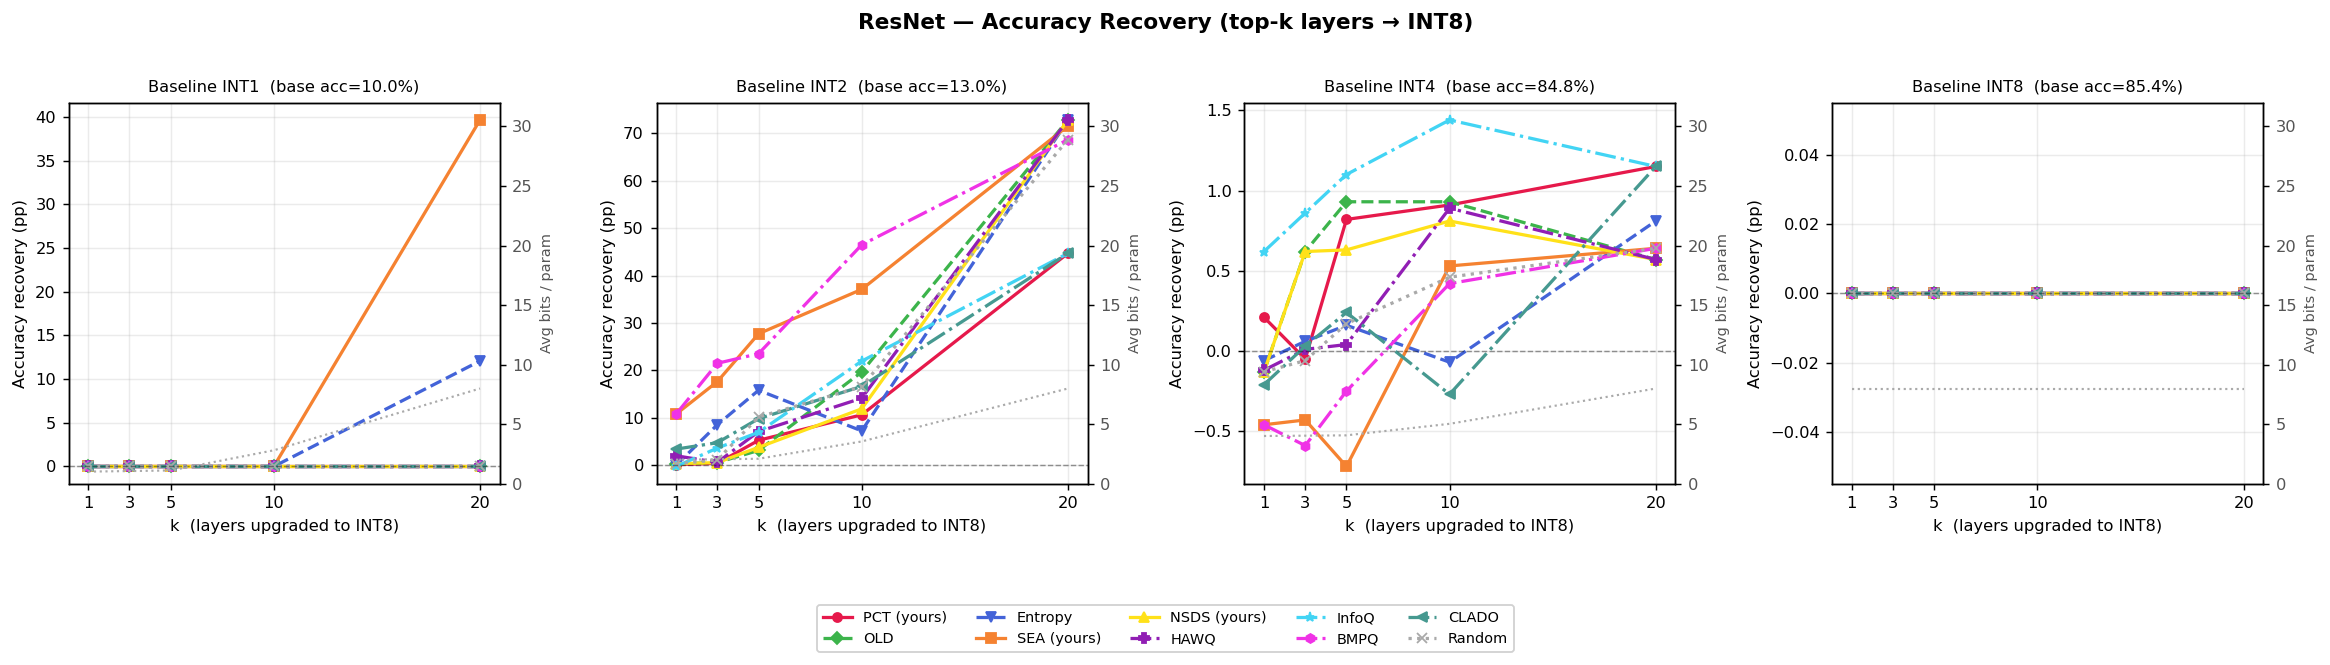

Saved → resnet_accuracy_recovery.png


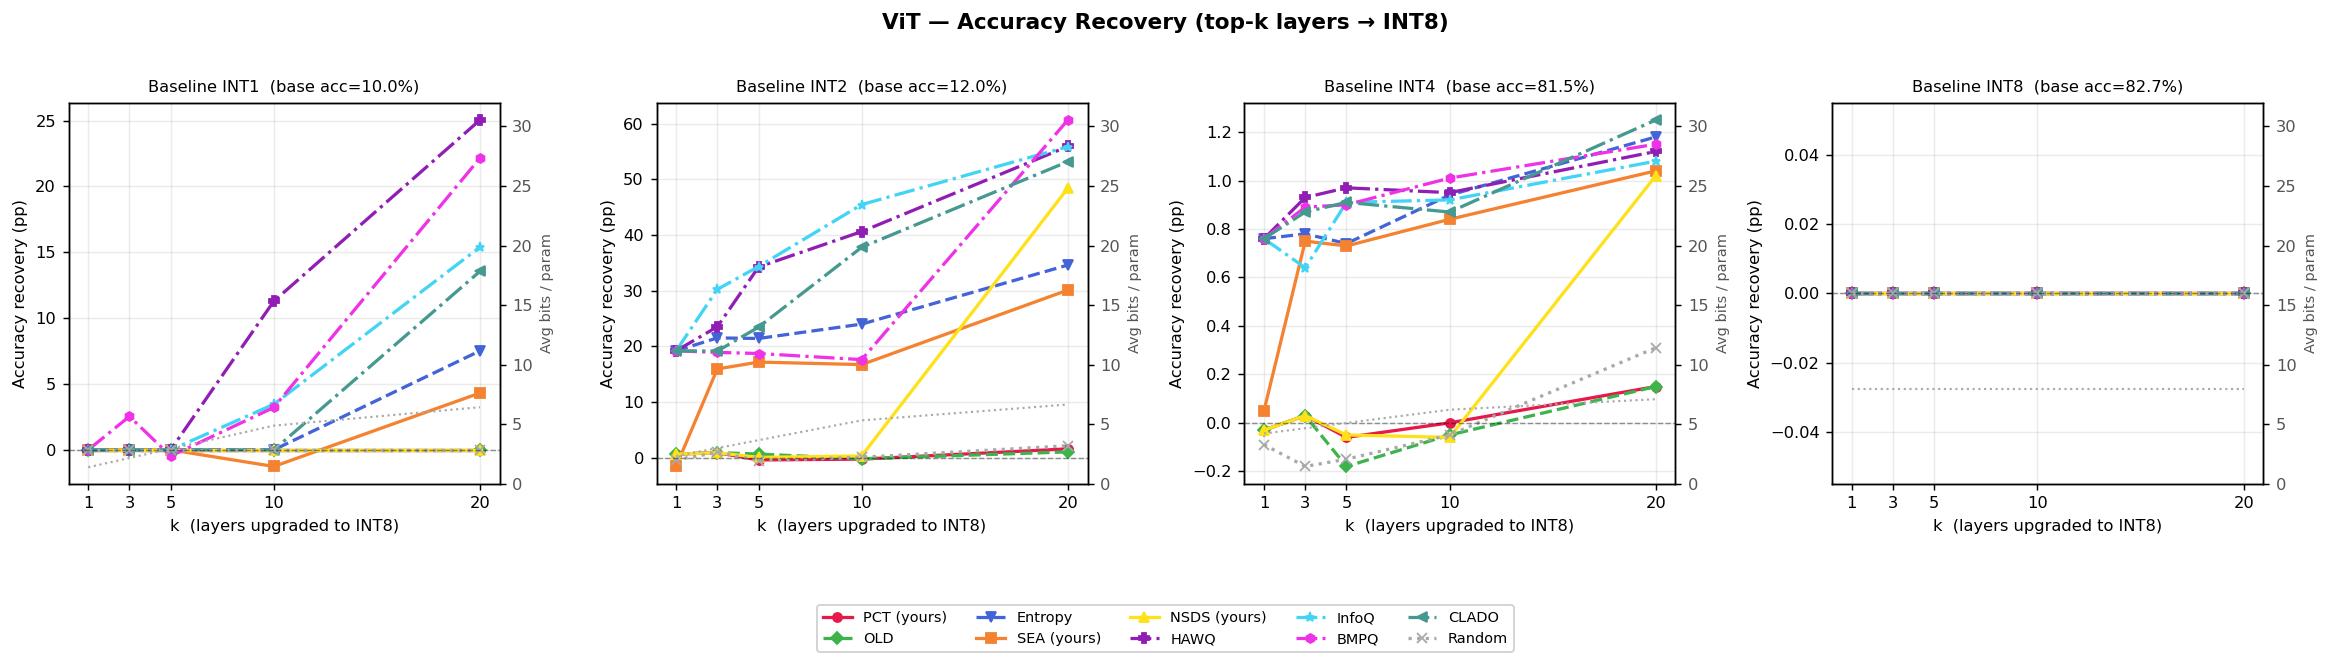

Saved → vit_accuracy_recovery.png


In [16]:
def plot_accuracy_recovery(results_df: pd.DataFrame, arch: str):
    df = results_df[results_df['arch'] == arch].copy()
    methods_in_df = [m for m in ALL_METHODS if m in df['method'].unique()]
    bits_list = sorted(df['bits_low'].dropna().unique())
    bits_list = [b for b in bits_list if b < 32]  # exclude fp32 placeholder

    ncols = len(bits_list)
    fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 4.5), sharey=False)
    if ncols == 1: axes = [axes]
    fig.suptitle(f'{arch} — Accuracy Recovery (top-k layers → INT8)',
                 fontsize=12, fontweight='bold')

    for ax, bits in zip(axes, bits_list):
        # Baseline accuracy
        base_row = results_df[
            (results_df['arch'] == arch) &
            (results_df['method'] == f'baseline_int{int(bits)}')]
        base_acc = float(base_row['accuracy'].values[0]) * 100 if len(base_row) else 0

        for method in methods_in_df:
            sub = df[(df['method'] == method) & (df['bits_low'] == bits)]\
                    .sort_values('k')
            if sub.empty: continue
            st = METHOD_STYLE.get(method, {})
            ax.plot(sub['k'], sub['acc_recovery'] * 100,
                    color=st.get('color', 'k'),
                    linestyle=st.get('linestyle', '-'),
                    marker=st.get('marker', 'o'),
                    label=st.get('label', method),
                    linewidth=1.8, markersize=5)

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)

        # Memory annotation (right axis)
        ax2 = ax.twinx()
        ax2.set_ylabel('Avg bits / param', fontsize=8, color='#555')
        ax2.yaxis.set_tick_params(labelcolor='#555')
        for method in methods_in_df[:1]:  # just show one line for clarity
            sub = df[(df['method'] == method) & (df['bits_low'] == bits)]\
                    .sort_values('k')
            if sub.empty: continue
            ax2.plot(sub['k'], sub['avg_bits'],
                     color='#aaa', linestyle=':', linewidth=1.2, label='avg bits')
        ax2.set_ylim(0, 32)

        ax.set_title(f'Baseline INT{int(bits)}  (base acc={base_acc:.1f}%)',
                     fontsize=9)
        ax.set_xlabel('k  (layers upgraded to INT8)', fontsize=9)
        ax.set_ylabel('Accuracy recovery (pp)', fontsize=9)
        ax.set_xticks(TOPK_LIST)
        ax.grid(alpha=0.25)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=5,
               bbox_to_anchor=(0.5, -0.02), fontsize=8, framealpha=0.9)
    plt.tight_layout(rect=[0, 0.06, 1, 0.96])
    out = OUT_DIR / f'{arch.lower()}_accuracy_recovery.png'
    plt.savefig(out, bbox_inches='tight')
    plt.show(); print(f'Saved → {out.name}')


if RUN_RESNET:
    plot_accuracy_recovery(all_results, 'ResNet')
if RUN_VIT:
    plot_accuracy_recovery(all_results, 'ViT')

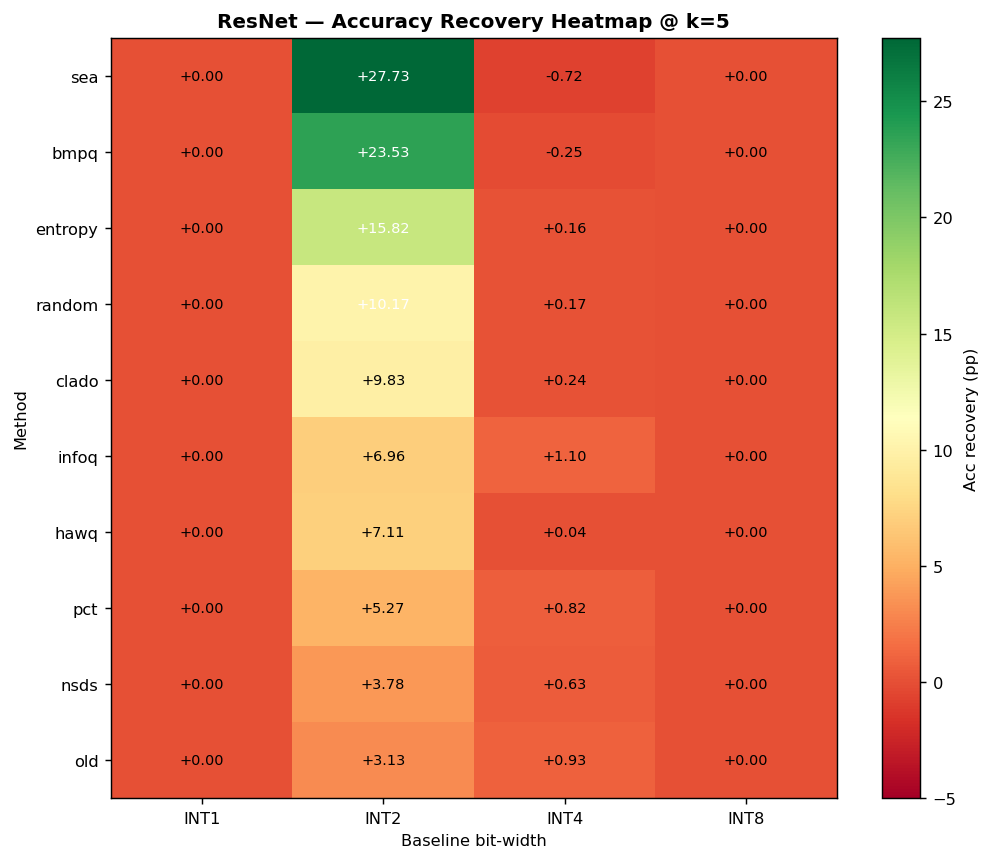

Saved → resnet_accuracy_heatmap_k5.png


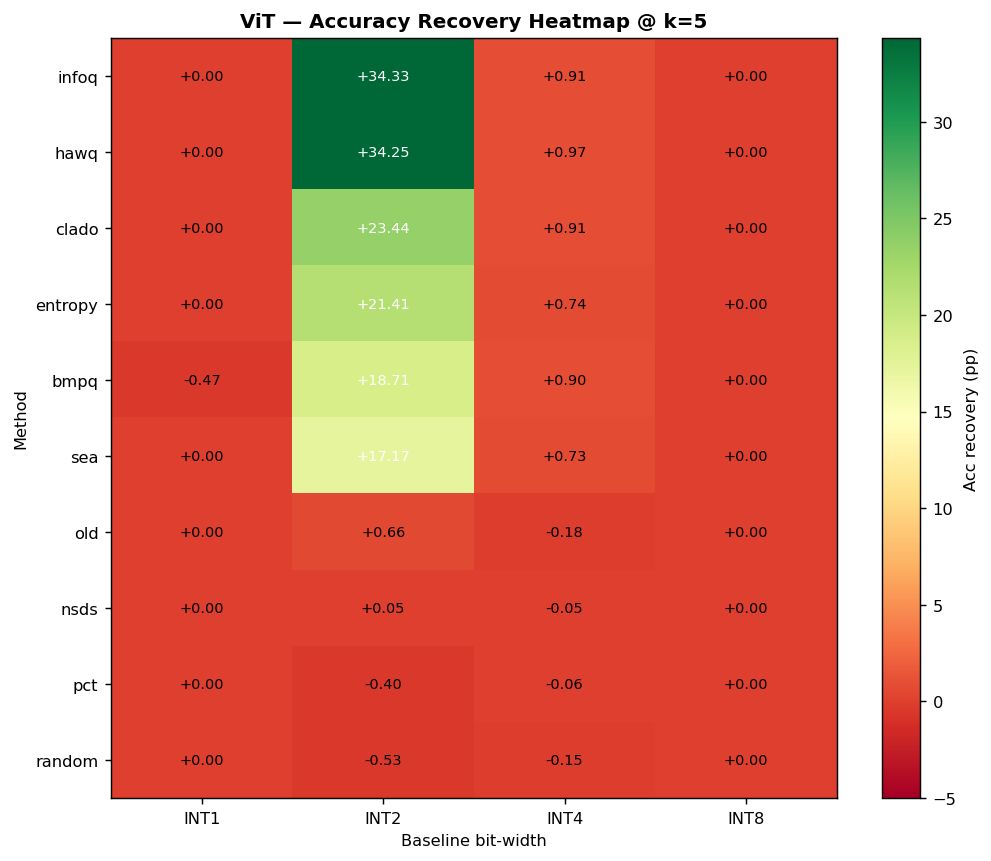

Saved → vit_accuracy_heatmap_k5.png


In [17]:
# ── Accuracy recovery heatmap: method × bit-width at k=5 ──────────────────────

def plot_recovery_heatmap(results_df: pd.DataFrame, arch: str, k_target: int = 5):
    df  = results_df[
        (results_df['arch'] == arch) &
        (results_df['method'].isin(ALL_METHODS)) &
        (results_df['k'] == k_target)
    ].copy()

    pivot = df.pivot_table(index='method', columns='bits_low',
                           values='acc_recovery', aggfunc='mean') * 100
    pivot.columns = [f'INT{int(c)}' for c in pivot.columns]

    # Order methods by average recovery
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(len(pivot.columns) * 1.5 + 2, len(pivot) * 0.55 + 1.2))
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=-5, vmax=max(5, pivot.values.max()))
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=8,
                    color='black' if abs(v) < 10 else 'white')
    plt.colorbar(im, ax=ax, label='Acc recovery (pp)')
    ax.set_title(f'{arch} — Accuracy Recovery Heatmap @ k={k_target}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Baseline bit-width'); ax.set_ylabel('Method')
    plt.tight_layout()
    out = OUT_DIR / f'{arch.lower()}_accuracy_heatmap_k{k_target}.png'
    plt.savefig(out, bbox_inches='tight')
    plt.show(); print(f'Saved → {out.name}')
    return pivot


if RUN_RESNET:
    rn_hm = plot_recovery_heatmap(all_results, 'ResNet', k_target=5)
if RUN_VIT:
    vit_hm = plot_recovery_heatmap(all_results, 'ViT', k_target=5)

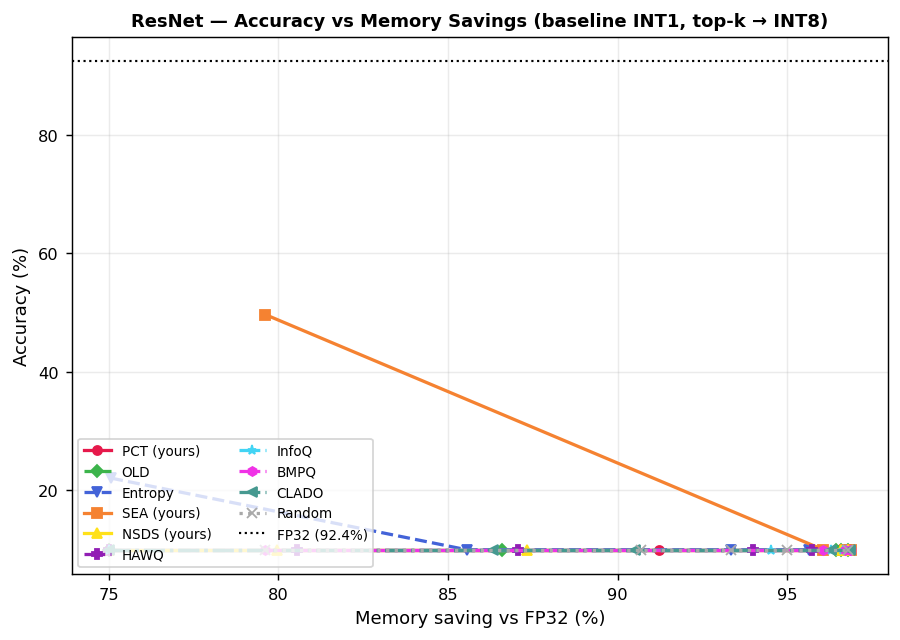

Saved → resnet_pareto_int1.png


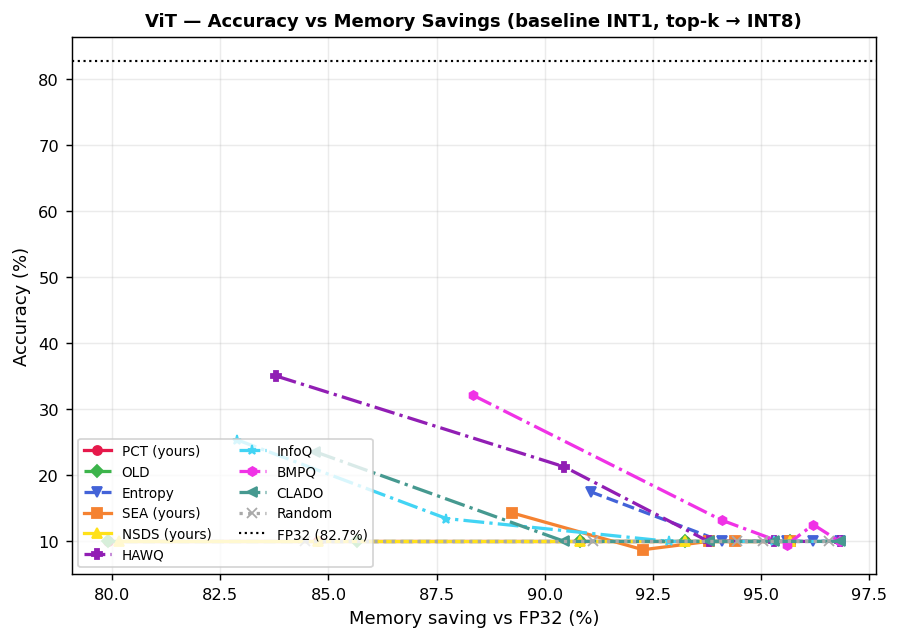

Saved → vit_pareto_int1.png


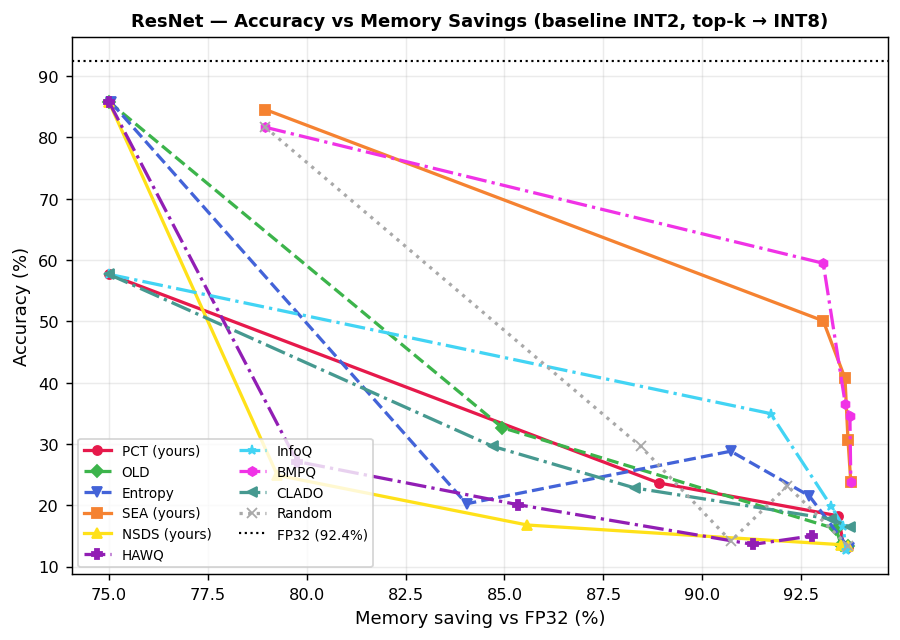

Saved → resnet_pareto_int2.png


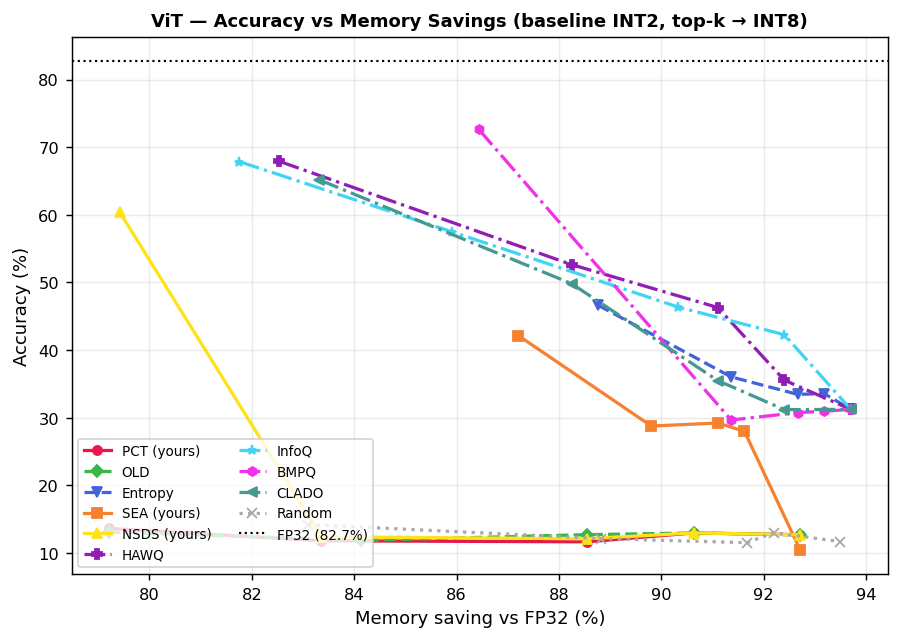

Saved → vit_pareto_int2.png


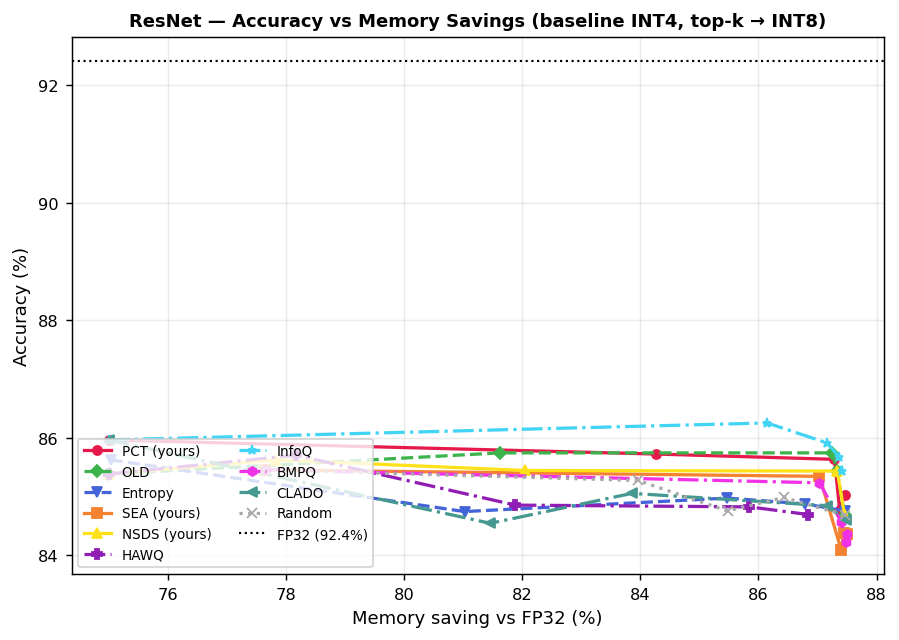

Saved → resnet_pareto_int4.png


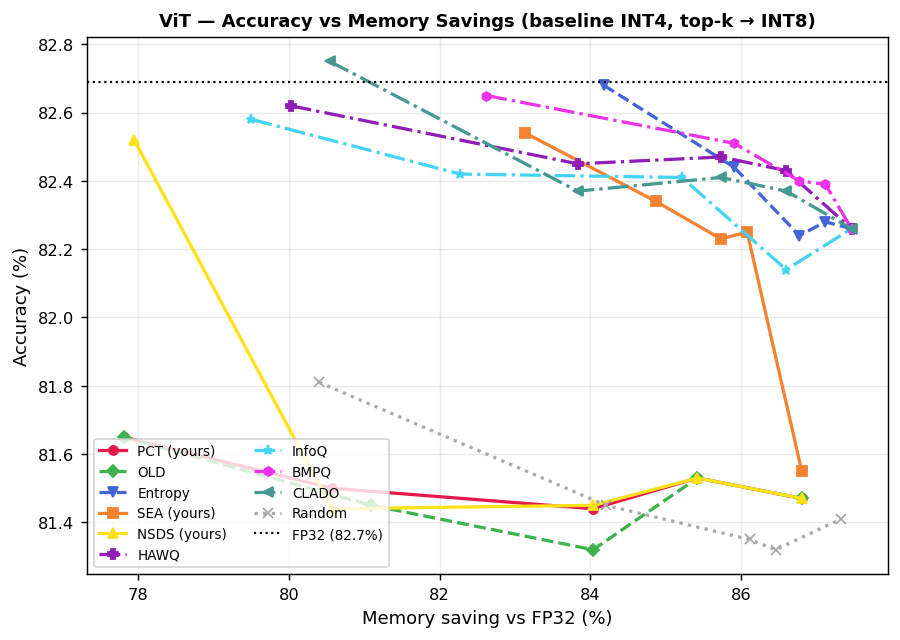

Saved → vit_pareto_int4.png


In [18]:
# ── Accuracy vs Memory savings (Pareto) ───────────────────────────────────────

def plot_pareto(
    results_df: pd.DataFrame,
    arch: str,
    bits_low: int = 4,
):
    df = results_df[
        (results_df['arch'] == arch) &
        (results_df['method'].isin(ALL_METHODS)) &
        (results_df['bits_low'] == bits_low)
    ].copy()
    fp32_acc = float(results_df[
        (results_df['arch'] == arch) & (results_df['method'] == 'fp32')
    ]['accuracy'].values[0]) * 100

    fig, ax = plt.subplots(figsize=(7, 5))
    for method in ALL_METHODS:
        sub = df[df['method'] == method].sort_values('saving_vs_fp32')
        if sub.empty: continue
        st = METHOD_STYLE.get(method, {})
        ax.plot(sub['saving_vs_fp32'] * 100, sub['accuracy'] * 100,
                color=st.get('color', 'k'),
                linestyle=st.get('linestyle', '-'),
                marker=st.get('marker', 'o'),
                label=st.get('label', method),
                linewidth=1.8, markersize=5)

    ax.axhline(fp32_acc, color='black', linestyle=':', linewidth=1.2, label=f'FP32 ({fp32_acc:.1f}%)')
    ax.set_xlabel('Memory saving vs FP32 (%)', fontsize=10)
    ax.set_ylabel('Accuracy (%)', fontsize=10)
    ax.set_title(f'{arch} — Accuracy vs Memory Savings (baseline INT{bits_low}, top-k → INT8)',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=7.5, ncol=2, loc='lower left')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    out = OUT_DIR / f'{arch.lower()}_pareto_int{bits_low}.png'
    plt.savefig(out, bbox_inches='tight')
    plt.show(); print(f'Saved → {out.name}')


for bits in [1, 2, 4]:
    if RUN_RESNET: plot_pareto(all_results, 'ResNet', bits)
    if RUN_VIT:   plot_pareto(all_results, 'ViT',    bits)

## Calibration Section — ECE / NLL / Brier
Same mixed-precision protocol, same bit-width scenarios.  
**Lower is better** for all calibration metrics.

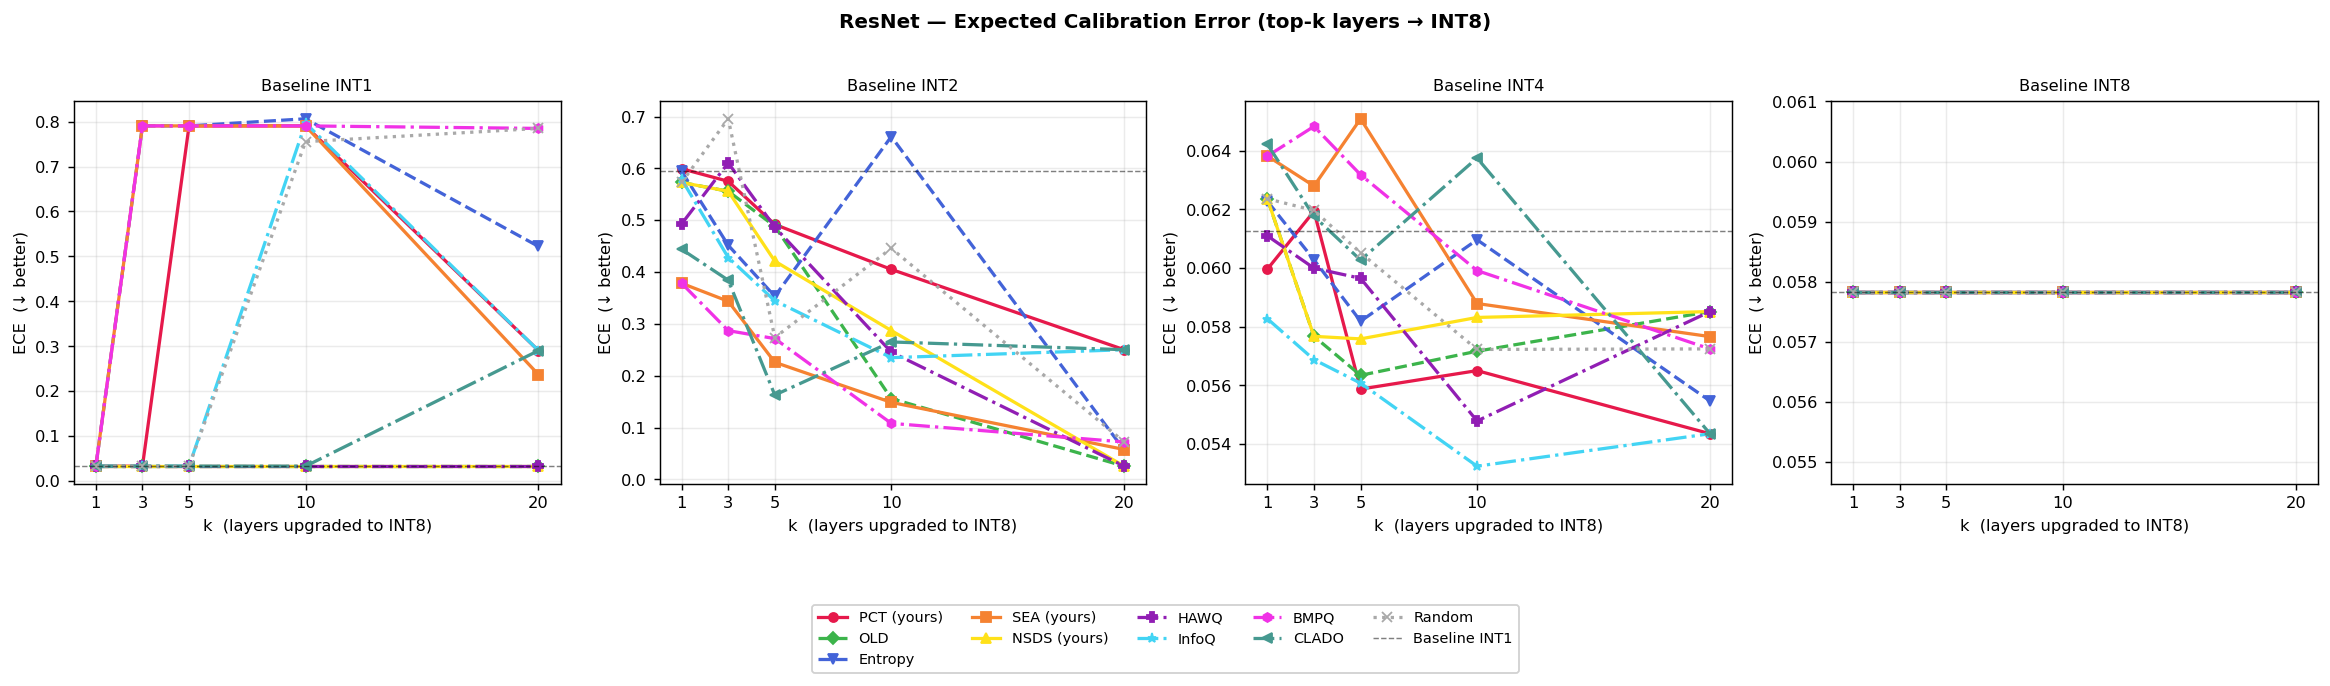

Saved → resnet_calibration_ece.png


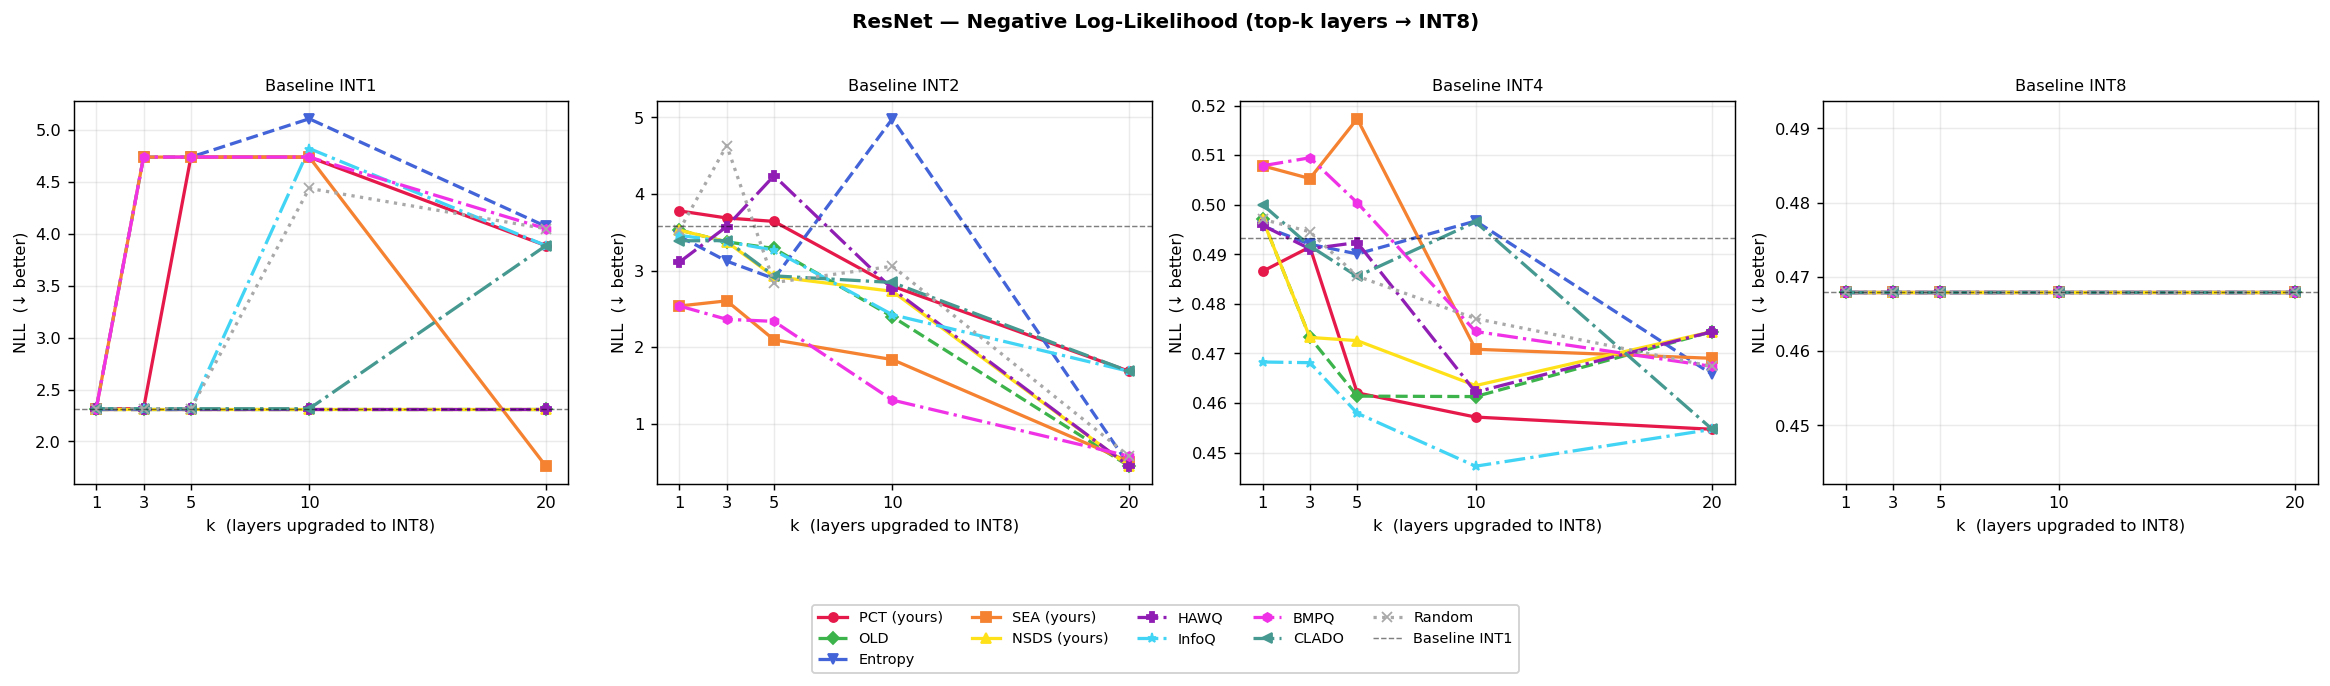

Saved → resnet_calibration_nll.png


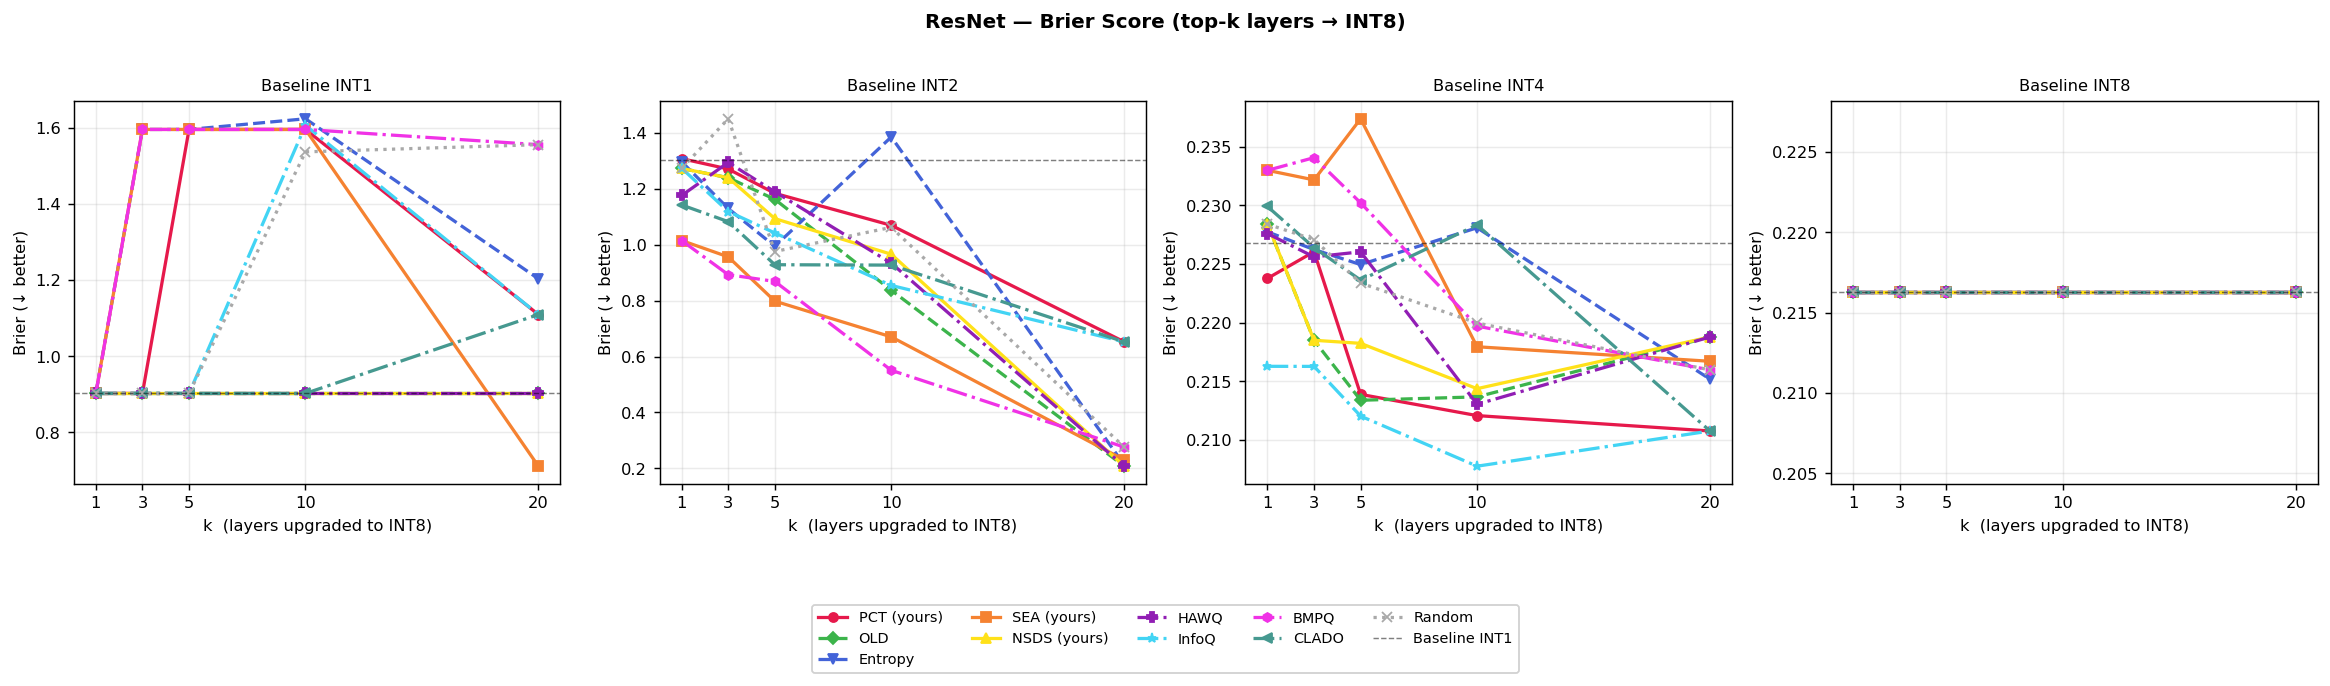

Saved → resnet_calibration_brier.png


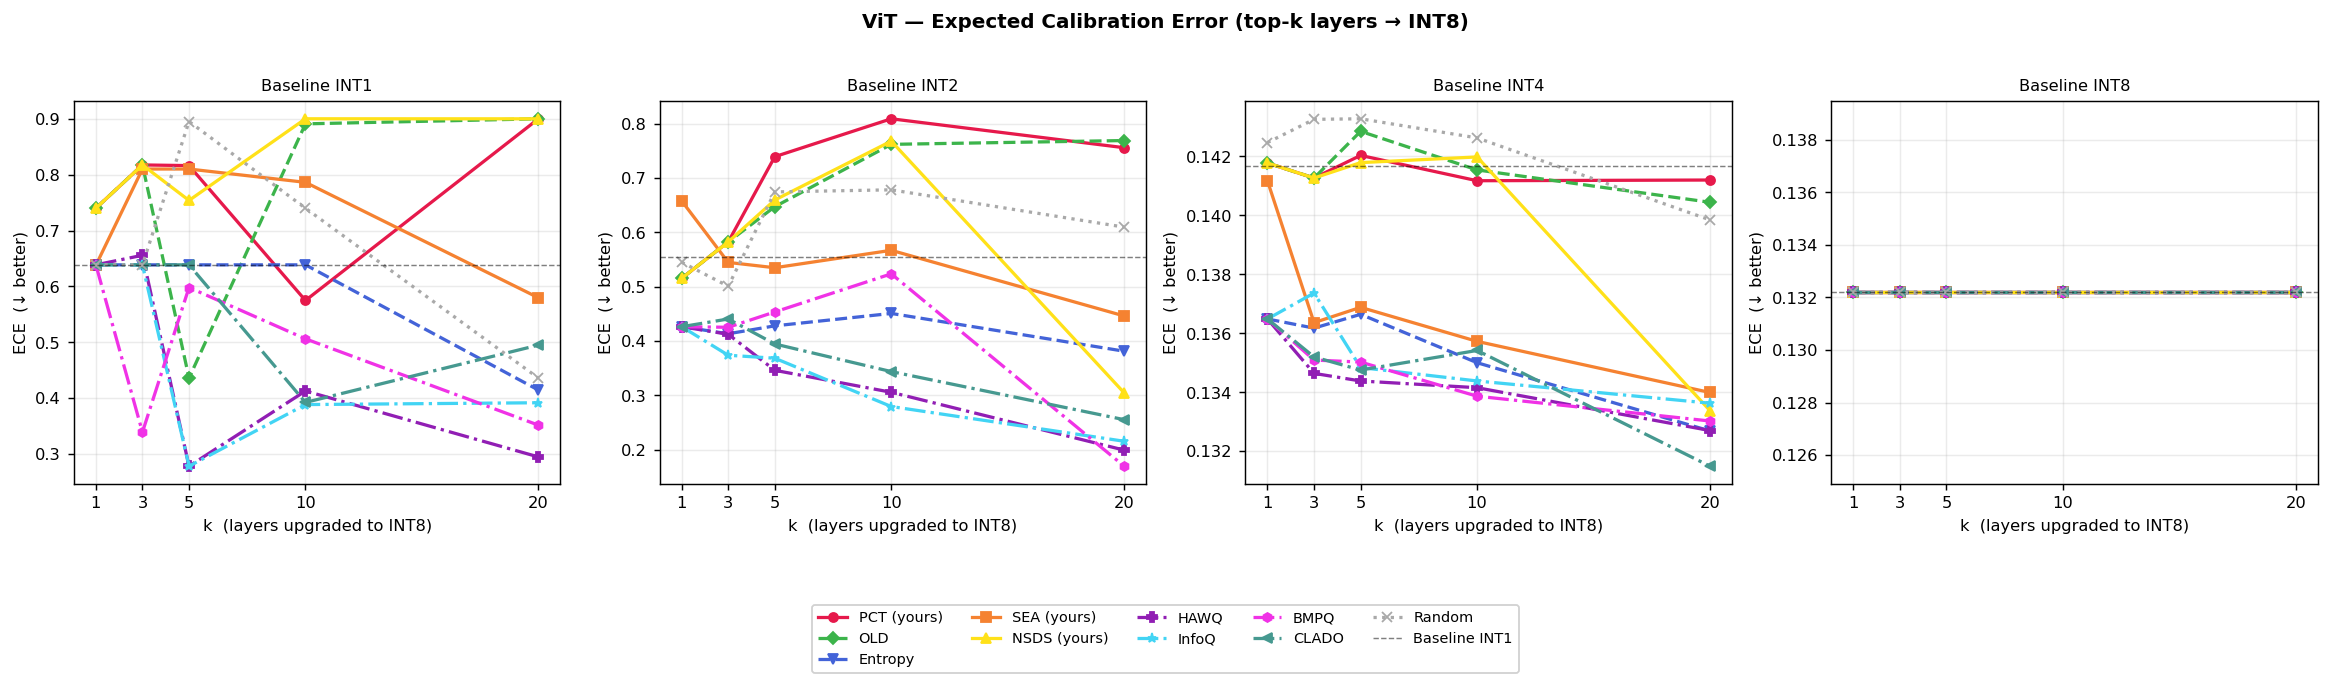

Saved → vit_calibration_ece.png


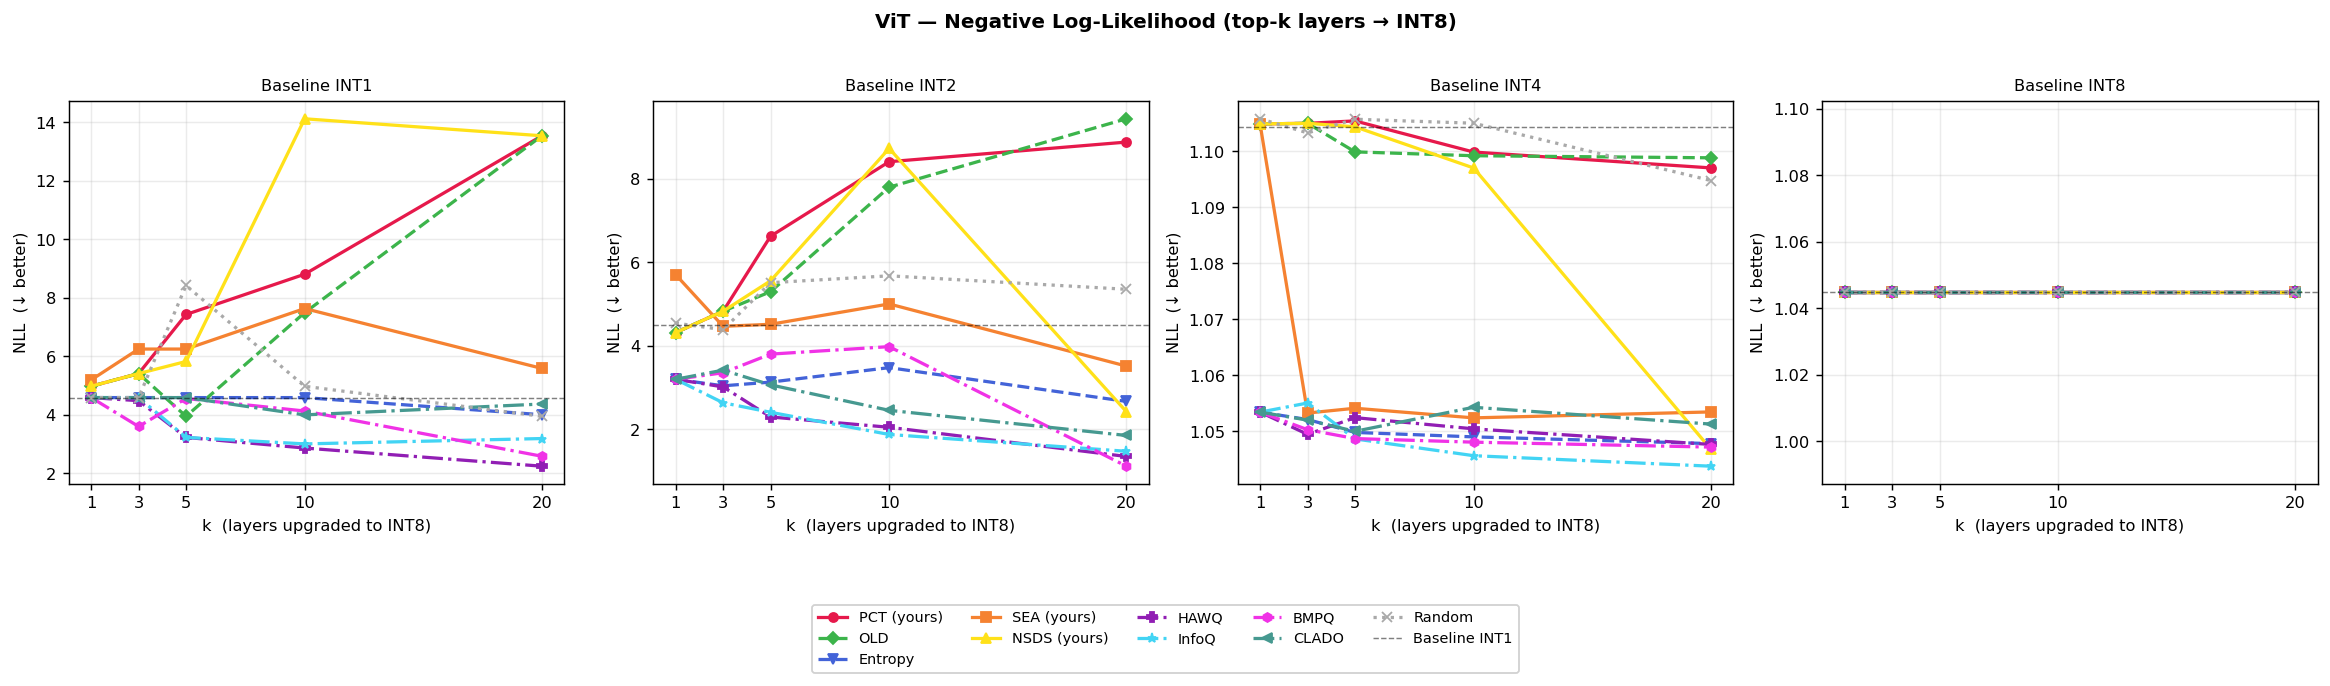

Saved → vit_calibration_nll.png


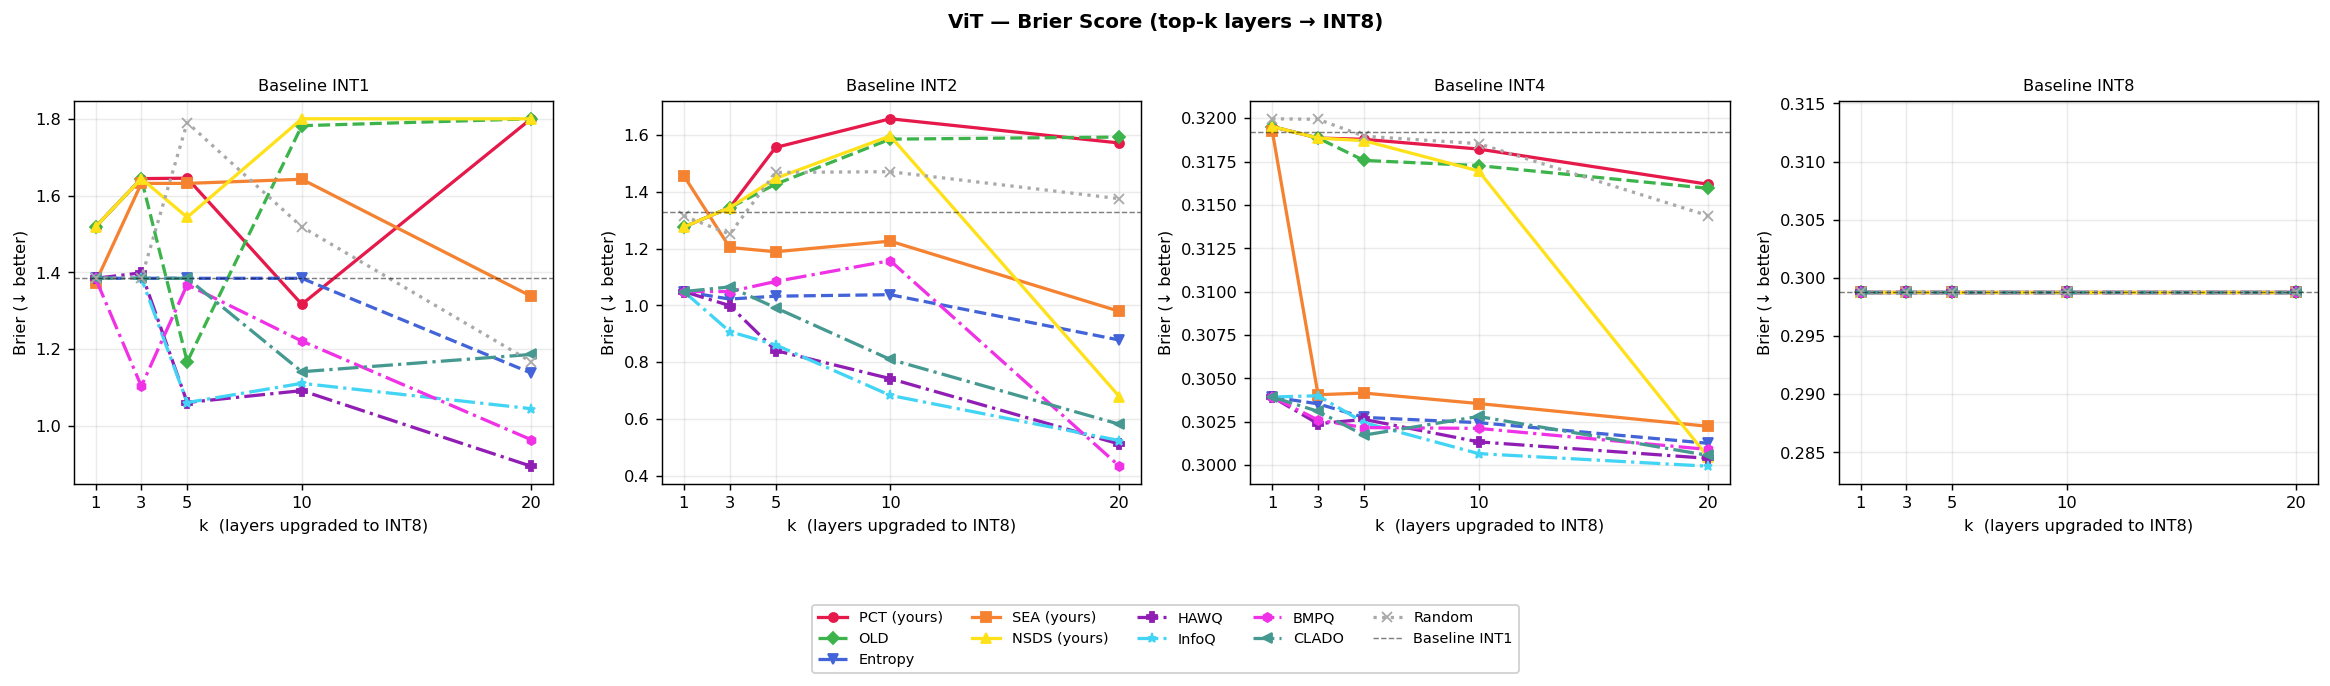

Saved → vit_calibration_brier.png


In [19]:
CALIB_METRICS = [
    ('ece',   'ECE  (↓ better)',   'Expected Calibration Error'),
    ('nll',   'NLL  (↓ better)',   'Negative Log-Likelihood'),
    ('brier', 'Brier (↓ better)',  'Brier Score'),
]


def plot_calibration_sweep(results_df: pd.DataFrame, arch: str):
    df = results_df[
        (results_df['arch'] == arch) &
        (results_df['method'].isin(ALL_METHODS))
    ].copy()
    methods_in_df = [m for m in ALL_METHODS if m in df['method'].unique()]
    bits_list = sorted([b for b in df['bits_low'].dropna().unique() if b < 32])

    for metric, ylabel, title_part in CALIB_METRICS:
        ncols = len(bits_list)
        fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 4.5), sharey=False)
        if ncols == 1: axes = [axes]
        fig.suptitle(f'{arch} — {title_part} (top-k layers → INT8)',
                     fontsize=11, fontweight='bold')

        for ax, bits in zip(axes, bits_list):
            base_row = results_df[
                (results_df['arch'] == arch) &
                (results_df['method'] == f'baseline_int{int(bits)}')]
            base_val = float(base_row[metric].values[0]) if len(base_row) else 0

            for method in methods_in_df:
                sub = df[(df['method'] == method) & (df['bits_low'] == bits)]\
                        .sort_values('k')
                if sub.empty: continue
                st = METHOD_STYLE.get(method, {})
                ax.plot(sub['k'], sub[metric],
                        color=st.get('color', 'k'),
                        linestyle=st.get('linestyle', '-'),
                        marker=st.get('marker', 'o'),
                        label=st.get('label', method),
                        linewidth=1.8, markersize=5)

            ax.axhline(base_val, color='black', linewidth=0.8,
                       linestyle='--', alpha=0.5, label=f'Baseline INT{int(bits)}')
            ax.set_title(f'Baseline INT{int(bits)}', fontsize=9)
            ax.set_xlabel('k  (layers upgraded to INT8)', fontsize=9)
            ax.set_ylabel(ylabel, fontsize=9)
            ax.set_xticks(TOPK_LIST)
            ax.grid(alpha=0.25)

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', ncol=5,
                   bbox_to_anchor=(0.5, -0.02), fontsize=8, framealpha=0.9)
        plt.tight_layout(rect=[0, 0.06, 1, 0.96])
        out = OUT_DIR / f'{arch.lower()}_calibration_{metric}.png'
        plt.savefig(out, bbox_inches='tight')
        plt.show(); print(f'Saved → {out.name}')


if RUN_RESNET: plot_calibration_sweep(all_results, 'ResNet')
if RUN_VIT:   plot_calibration_sweep(all_results, 'ViT')

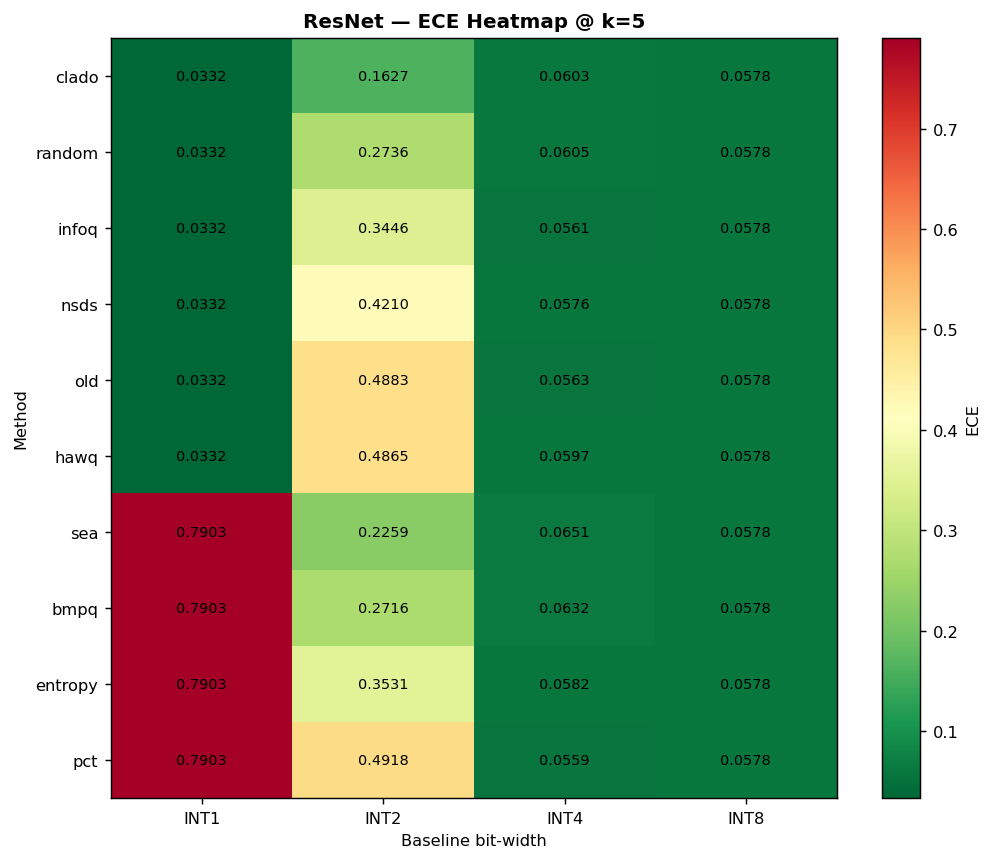

Saved → resnet_calib_ece_heatmap_k5.png


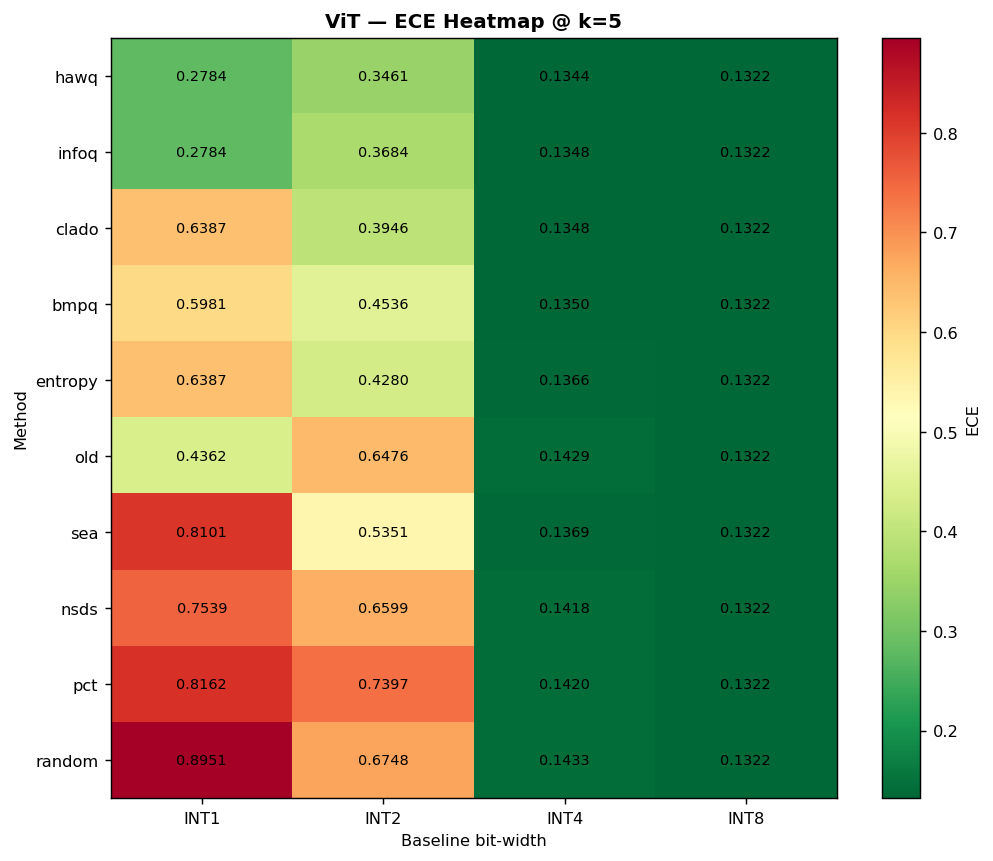

Saved → vit_calib_ece_heatmap_k5.png


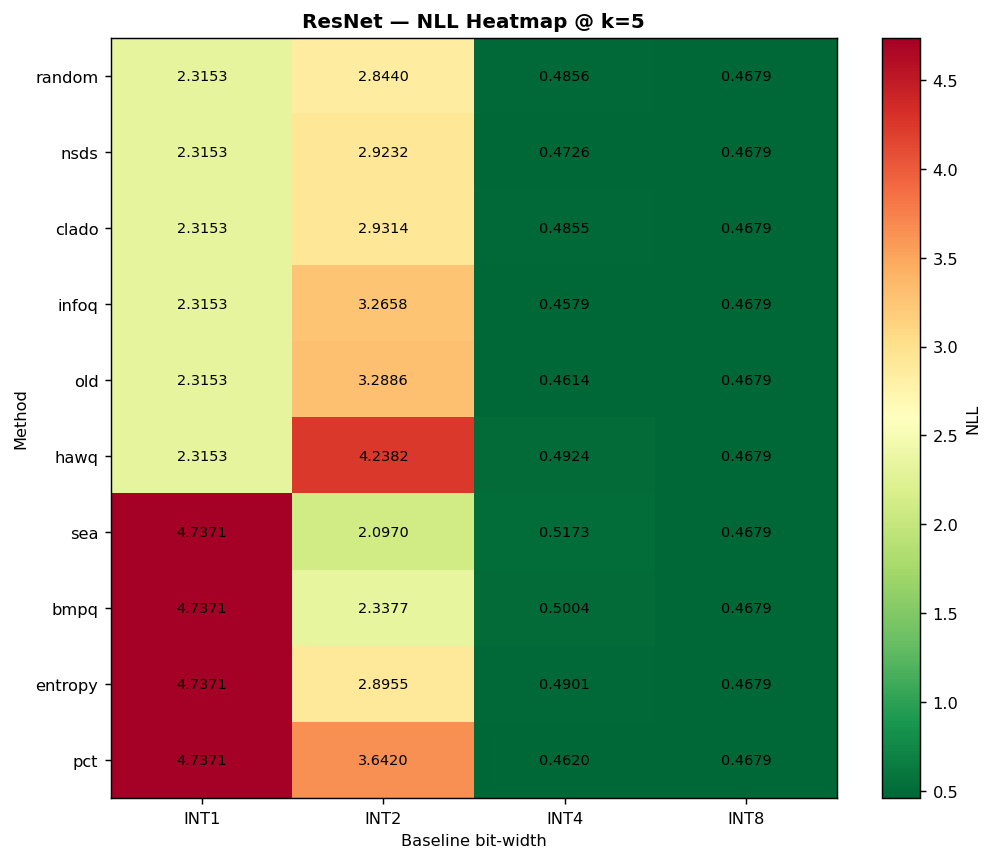

Saved → resnet_calib_nll_heatmap_k5.png


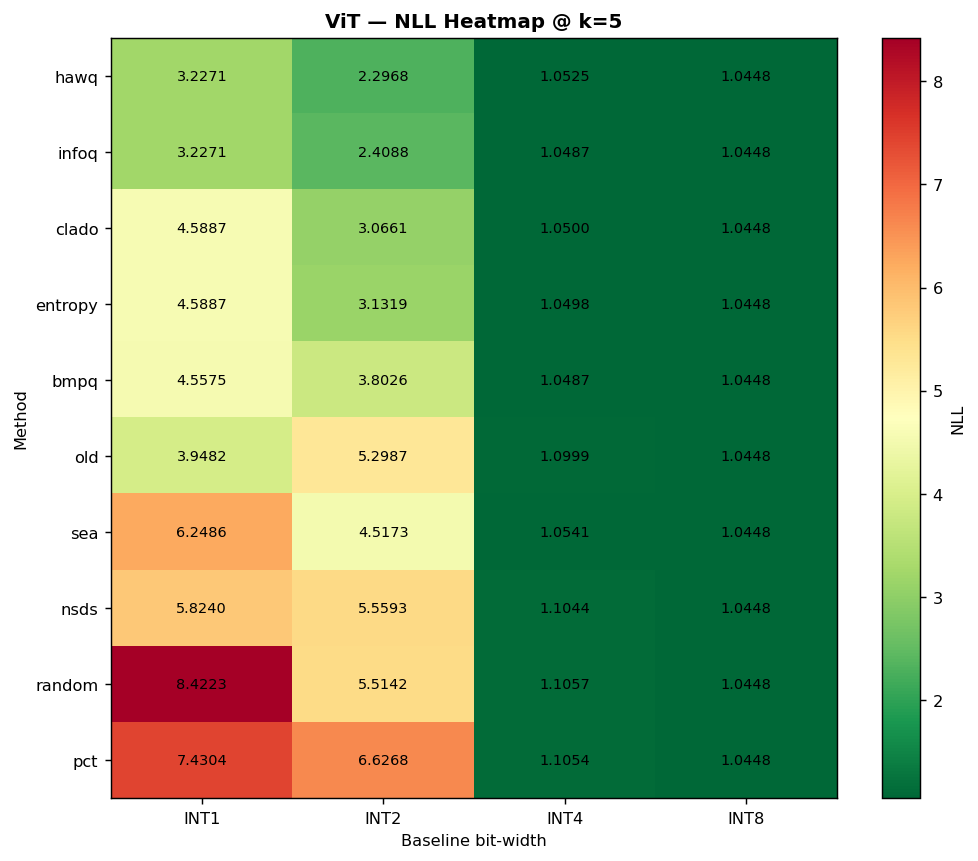

Saved → vit_calib_nll_heatmap_k5.png


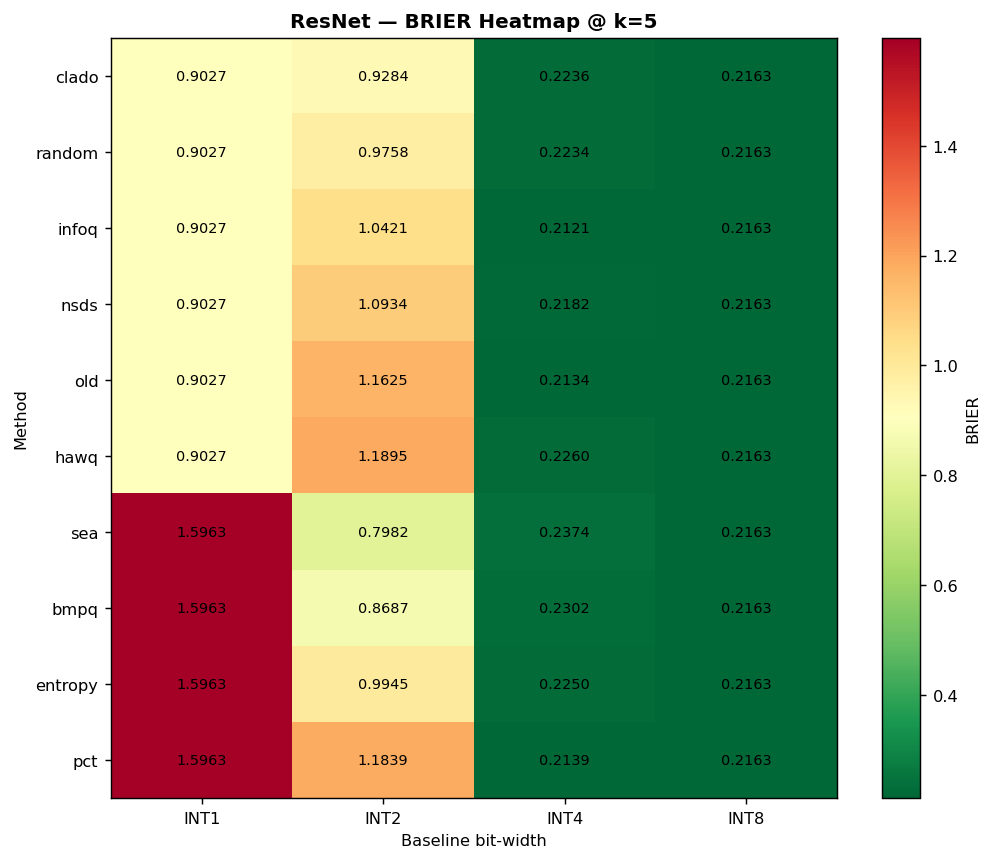

Saved → resnet_calib_brier_heatmap_k5.png


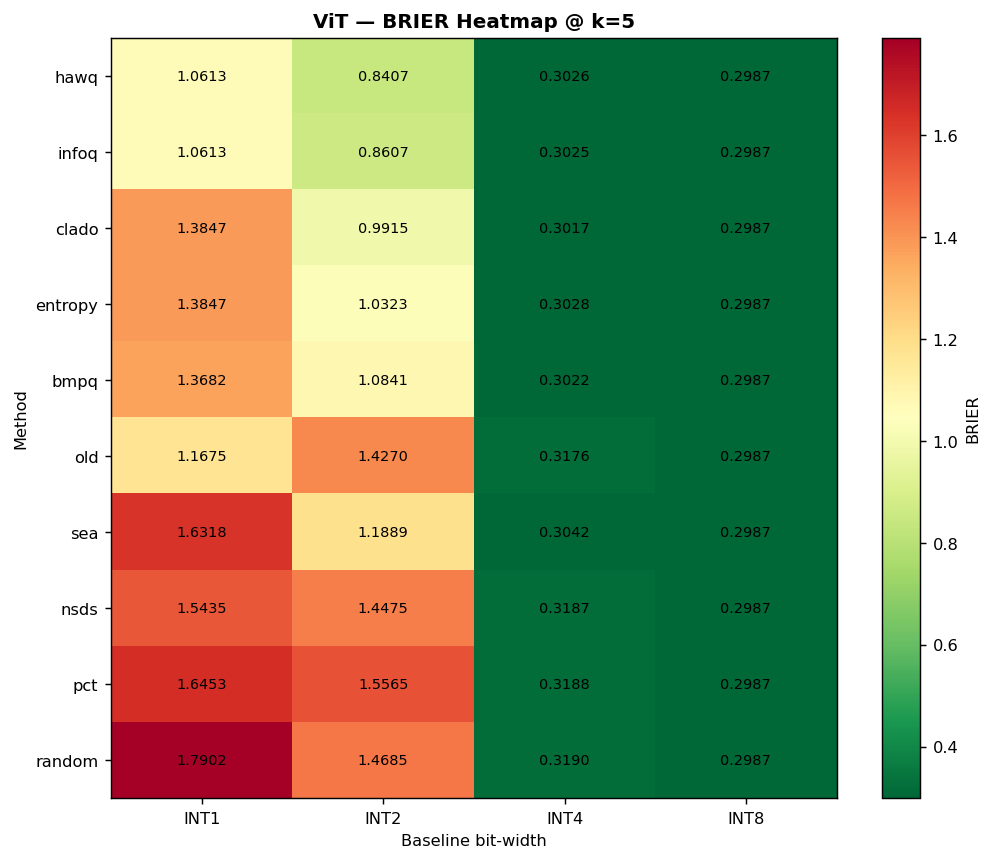

Saved → vit_calib_brier_heatmap_k5.png


In [20]:
# ── Calibration heatmap: ECE  at k=5 ─────────────────────────────────────────

def plot_calibration_heatmap(
    results_df: pd.DataFrame, arch: str, metric: str = 'ece', k_target: int = 5
):
    df = results_df[
        (results_df['arch'] == arch) &
        (results_df['method'].isin(ALL_METHODS)) &
        (results_df['k'] == k_target)
    ].copy()

    pivot = df.pivot_table(index='method', columns='bits_low',
                           values=metric, aggfunc='mean')
    pivot.columns = [f'INT{int(c)}' for c in pivot.columns]
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]  # lower is better

    fig, ax = plt.subplots(figsize=(len(pivot.columns) * 1.5 + 2, len(pivot) * 0.55 + 1.2))
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f'{pivot.values[i,j]:.4f}',
                    ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, label=metric.upper())
    ax.set_title(f'{arch} — {metric.upper()} Heatmap @ k={k_target}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Baseline bit-width'); ax.set_ylabel('Method')
    plt.tight_layout()
    out = OUT_DIR / f'{arch.lower()}_calib_{metric}_heatmap_k{k_target}.png'
    plt.savefig(out, bbox_inches='tight')
    plt.show(); print(f'Saved → {out.name}')
    return pivot


for metric in ['ece', 'nll', 'brier']:
    if RUN_RESNET: plot_calibration_heatmap(all_results, 'ResNet', metric)
    if RUN_VIT:   plot_calibration_heatmap(all_results, 'ViT',    metric)

In [25]:
# ── Summary table: AUC across k values ────────────────────────────────────────

def auc_summary(results_df: pd.DataFrame) -> pd.DataFrame:
    """
    For each (arch, method, bits_low), compute area under curve (trapezoid)
    for acc_recovery and ECE over k values.
    """
    rows = []
    for arch in results_df['arch'].unique():
        for method in ALL_METHODS:
            for bits in BASELINE_BITS:
                sub = results_df[
                    (results_df['arch'] == arch) &
                    (results_df['method'] == method) &
                    (results_df['bits_low'] == bits)
                ].sort_values('k')
                if len(sub) < 2: continue
                _trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
                auc_acc = float(_trapz(sub['acc_recovery'] * 100, sub['k']))
                auc_ece = float(_trapz(sub['ece'], sub['k']))
                rows.append({
                    'arch': arch, 'method': method,
                    'bits_low': int(bits),
                    'auc_acc_recovery_pp': round(auc_acc, 4),
                    'auc_ece': round(auc_ece, 6),
                })
    return pd.DataFrame(rows)


summary = auc_summary(all_results)
summary.to_csv(OUT_DIR / 'auc_summary.csv', index=False)

# Pretty-print: pivot method vs bit-width for accuracy AUC
for arch in summary['arch'].unique():
    print(f'\n━━━ {arch} — Accuracy Recovery AUC (↑ better) ━━━')
    pivot = summary[summary['arch'] == arch].pivot_table(
        index='method', columns='bits_low',
        values='auc_acc_recovery_pp', aggfunc='mean'
    )
    pivot.columns = [f'INT{c}' for c in pivot.columns]
    pivot['mean'] = pivot.mean(axis=1)
    pivot = pivot.sort_values('mean', ascending=False)
    display(pivot.round(3))

for arch in summary['arch'].unique():
    print(f'\n━━━ {arch} — ECE AUC (↓ better) ━━━')
    pivot = summary[summary['arch'] == arch].pivot_table(
        index='method', columns='bits_low',
        values='auc_ece', aggfunc='mean'
    )
    pivot.columns = [f'INT{c}' for c in pivot.columns]
    pivot['mean'] = pivot.mean(axis=1)
    pivot = pivot.sort_values('mean', ascending=True)
    display(pivot.round(6))


━━━ ResNet — Accuracy Recovery AUC (↑ better) ━━━


,INT1,INT2,INT4,INT8,mean
method,,,,,
sea,198.35,779.050,3.335,0.0,245.184
bmpq,0.00,828.045,3.835,0.0,207.970
entropy,60.40,490.505,4.145,0.0,138.762
old,0.00,523.895,14.190,0.0,134.521
random,0.00,505.920,6.995,0.0,128.229
hawq,0.00,498.225,9.565,0.0,126.948
nsds,0.00,467.970,12.240,0.0,120.053
infoq,0.00,419.520,22.740,0.0,110.565
clado,0.00,395.510,4.415,0.0,99.981



━━━ ViT — Accuracy Recovery AUC (↑ better) ━━━


,INT1,INT2,INT4,INT8,mean
method,,,,,
hawq,209.925,770.035,18.740,0.0,249.675
infoq,102.950,819.880,17.525,0.0,235.089
clado,67.800,688.680,18.460,0.0,193.735
bmpq,138.385,557.770,19.015,0.0,178.792
entropy,37.600,490.020,17.860,0.0,136.370
sea,12.150,366.305,15.605,0.0,98.515
nsds,0.000,247.160,4.505,0.0,62.916
random,0.000,11.035,0.200,0.0,2.809
old,0.000,8.595,-0.225,0.0,2.093



━━━ ResNet — ECE AUC (↓ better) ━━━


,INT1,INT2,INT4,INT8,mean
method,,,,,
old,0.631499,4.690324,1.096231,1.098594,1.879162
hawq,0.631499,5.384932,1.093353,1.098594,2.052094
nsds,0.631499,5.438312,1.109210,1.098594,2.069404
clado,1.917487,5.020707,1.148609,1.098594,2.296349
infoq,7.642372,5.652463,1.039389,1.098594,3.858204
sea,11.492613,3.258084,1.146488,1.098594,4.248945
random,9.804027,6.624619,1.113524,1.098594,4.660191
bmpq,14.231411,3.073889,1.150203,1.098594,4.888524
pct,10.245726,7.759181,1.074936,1.098594,5.044609



━━━ ViT — ECE AUC (↓ better) ━━━


,INT1,INT2,INT4,INT8,mean
method,,,,,
hawq,7.497521,5.750026,2.545790,2.511602,4.576235
infoq,7.765594,5.635369,2.559184,2.511602,4.617937
clado,9.570910,6.542638,2.551628,2.511602,5.294195
bmpq,8.967539,7.640591,2.548388,2.511602,5.417030
entropy,11.014938,8.039541,2.563061,2.511602,6.032286
sea,13.889499,10.105824,2.580897,2.511602,7.271956
random,12.779381,12.048108,2.699391,2.511602,7.509620
nsds,16.262951,11.275431,2.652326,2.511602,8.175577
pct,14.042903,14.122385,2.686236,2.511602,8.340782


In [ ]:
# ── Spearman ρ: score ranking vs recovery ranking (ground truth agreement) ─────
# Uses k=all (every layer evaluated once) ground truth from the per-layer
# recovery values embedded in the sweep (k=1 per-layer proxies).
# We compare method scores to the acc recovery when only that 1 layer is upgraded.

def per_layer_recovery_gt(results_df, arch, bits):
    """k=1 recovery per method (approximation: average over all methods of k=1 rows)."""
    # The 'true' per-layer recovery is architecture-specific and cached in
    # layer_importance_ground_truth.ipynb. Here we average across methods.
    df = results_df[
        (results_df['arch'] == arch) &
        (results_df['k'] == 1) &
        (results_df['bits_low'] == bits)
    ]
    return df.groupby('method')['acc_recovery'].mean()


def spearman_vs_recovery(
    score_df: pd.DataFrame,
    results_df: pd.DataFrame,
    arch: str,
    layer_names: list[str],
):
    rows = []
    for bits in BASELINE_BITS:
        # Build per-layer ground truth: for each layer, get acc recovery at k=1
        # We approximate by checking which 1-layer was upgraded per method
        # (this gives the correct ground truth only when |top-1| = 1 layer is unique)
        for method in ALL_METHODS:
            col = METHOD_TO_COL.get(method)
            if col not in score_df.columns or score_df[col].isna().all():
                continue
            # Use the k=1 recovery of THIS method as a proxy for its top-layer's importance
            # True correlation requires per-layer ground truth (from the GT notebooks)
            method_scores = score_df.set_index('layer_name')[col].reindex(layer_names).fillna(0)
            # Check if GT notebook CSVs are available
            gt_path = (ROOT / 'results' / 'layer_importance_ground_truth' /
                       'per_layer_int8_over_1bit_recovery.csv')
            if gt_path.exists():
                gt = pd.read_csv(gt_path).set_index('layer_name')['acc_recovery_pp']
                aligned = method_scores.reindex(gt.index).fillna(0)
                gt_aligned = gt.reindex(aligned.index).fillna(0)
                rho, _ = spearmanr(aligned.values, gt_aligned.values)
                rows.append({'arch': arch, 'method': method, 'bits_low': bits,
                             'spearman_rho': round(rho, 4), 'gt_source': 'gt_notebook'})
            else:
                rows.append({'arch': arch, 'method': method, 'bits_low': bits,
                             'spearman_rho': float('nan'), 'gt_source': 'missing'})
    return pd.DataFrame(rows)


if RUN_RESNET:
    rn_rho = spearman_vs_recovery(rn_df, all_results, 'ResNet', RN_LAYER_NAMES)
    print('ResNet Spearman ρ:')
    display(rn_rho.pivot_table(index='method', columns='bits_low',
                                values='spearman_rho').round(3))
if RUN_VIT:
    vit_rho = spearman_vs_recovery(vit_df, all_results, 'ViT', VIT_LAYER_NAMES)
    print('ViT Spearman ρ:')
    display(vit_rho.pivot_table(index='method', columns='bits_low',
                                values='spearman_rho').round(3))

In [ ]:
# ── Combined 4-panel overview (one per architecture) ──────────────────────────

def plot_combined_overview(results_df: pd.DataFrame, arch: str, bits_low: int = 4):
    """
    2×2 grid for a single (arch, bits_low) scenario:
      [Acc recovery | ECE]
      [NLL          | Brier]
    """
    df = results_df[
        (results_df['arch'] == arch) &
        (results_df['method'].isin(ALL_METHODS)) &
        (results_df['bits_low'] == bits_low)
    ].copy()
    methods_in_df = [m for m in ALL_METHODS if m in df['method'].unique()]

    base_row = results_df[
        (results_df['arch'] == arch) &
        (results_df['method'] == f'baseline_int{bits_low}')
    ]
    base_acc = float(base_row['accuracy'].values[0]) * 100

    panels = [
        ('acc_recovery', 'Accuracy recovery (pp)', lambda v: v * 100, True,  'Acc Recovery'),
        ('ece',          'ECE',                    lambda v: v,        False, 'ECE'),
        ('nll',          'NLL',                    lambda v: v,        False, 'NLL'),
        ('brier',        'Brier score',            lambda v: v,        False, 'Brier'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()
    fig.suptitle(
        f'{arch} — Baseline INT{bits_low} → top-k layers INT8 | All methods',
        fontsize=12, fontweight='bold'
    )

    for ax, (col, ylabel, transform, higher_better, title) in zip(axes, panels):
        base_row2 = results_df[
            (results_df['arch'] == arch) &
            (results_df['method'] == f'baseline_int{bits_low}')
        ]
        base_val = transform(float(base_row2[col].values[0])) if len(base_row2) else 0

        for method in methods_in_df:
            sub = df[df['method'] == method].sort_values('k')
            if sub.empty: continue
            st = METHOD_STYLE.get(method, {})
            vals = transform(sub[col]) if not callable(transform) else sub[col].apply(transform)
            ax.plot(sub['k'], vals,
                    color=st.get('color', 'k'),
                    linestyle=st.get('linestyle', '-'),
                    marker=st.get('marker', 'o'),
                    label=st.get('label', method),
                    linewidth=1.8, markersize=5)

        ax.axhline(base_val, color='black', linewidth=0.9, linestyle='--',
                   alpha=0.5, label=f'Baseline INT{bits_low}')
        arrow = '↑' if higher_better else '↓'
        ax.set_title(f'{title} ({arrow} better)', fontsize=9)
        ax.set_xlabel('k  (layers → INT8)', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_xticks(TOPK_LIST); ax.grid(alpha=0.25)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5,
               bbox_to_anchor=(0.5, -0.04), fontsize=8.5, framealpha=0.95)
    plt.tight_layout(rect=[0, 0.06, 1, 0.98])
    out = OUT_DIR / f'{arch.lower()}_combined_int{bits_low}.png'
    plt.savefig(out, bbox_inches='tight')
    plt.show(); print(f'Saved → {out.name}')


for bits in [1, 2, 4]:
    if RUN_RESNET: plot_combined_overview(all_results, 'ResNet', bits)
    if RUN_VIT:   plot_combined_overview(all_results, 'ViT',    bits)

In [ ]:
# ── Memory savings bar chart at k=5, INT4 baseline ────────────────────────────

def plot_memory_bars(results_df: pd.DataFrame, arch: str, k_target: int = 5, bits_low: int = 4):
    df = results_df[
        (results_df['arch'] == arch) &
        (results_df['method'].isin(ALL_METHODS)) &
        (results_df['k'] == k_target) &
        (results_df['bits_low'] == bits_low)
    ].copy()

    # Sort by accuracy recovery
    df = df.sort_values('acc_recovery', ascending=False)
    labels = [METHOD_STYLE.get(m, {}).get('label', m) for m in df['method']]
    colors = [METHOD_STYLE.get(m, {}).get('color', '#888') for m in df['method']]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{arch} @ k={k_target} layers → INT8, rest INT{bits_low}',
                 fontsize=11, fontweight='bold')

    bars1 = ax1.barh(labels, df['acc_recovery'] * 100, color=colors, alpha=0.85)
    ax1.set_xlabel('Accuracy recovery over INT4 baseline (pp)')
    ax1.set_title('Accuracy Recovery (↑ better)')
    ax1.axvline(0, color='black', linewidth=0.8)
    ax1.bar_label(bars1, fmt='+%.2f pp', padding=3, fontsize=7.5)

    bars2 = ax2.barh(labels, df['saving_vs_fp32'] * 100, color=colors, alpha=0.85)
    ax2.set_xlabel('Memory saving vs FP32 (%)')
    ax2.set_title('Memory Efficiency (↑ better)')
    ax2.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=7.5)

    plt.tight_layout()
    out = OUT_DIR / f'{arch.lower()}_memory_bars_k{k_target}_int{bits_low}.png'
    plt.savefig(out, bbox_inches='tight')
    plt.show(); print(f'Saved → {out.name}')


if RUN_RESNET: plot_memory_bars(all_results, 'ResNet')
if RUN_VIT:   plot_memory_bars(all_results, 'ViT')

In [ ]:
# ── Final scorecard ───────────────────────────────────────────────────────────

print('=' * 70)
print(' FINAL SCORECARD: Accuracy Recovery AUC (↑ better)')
print('=' * 70)
if not summary.empty:
    for arch in summary['arch'].unique():
        df = summary[summary['arch'] == arch]
        pivot = df.pivot_table(index='method', columns='bits_low',
                               values='auc_acc_recovery_pp').fillna(float('nan'))
        pivot.columns = [f'INT{int(c)}' for c in pivot.columns]
        pivot['MEAN'] = pivot.mean(axis=1)
        pivot = pivot.sort_values('MEAN', ascending=False)
        print(f'\n{arch}:')
        print(pivot.round(2).to_string())

print('\n' + '=' * 70)
print(' FINAL SCORECARD: ECE AUC (↓ better)')
print('=' * 70)
if not summary.empty:
    for arch in summary['arch'].unique():
        df = summary[summary['arch'] == arch]
        pivot = df.pivot_table(index='method', columns='bits_low',
                               values='auc_ece').fillna(float('nan'))
        pivot.columns = [f'INT{int(c)}' for c in pivot.columns]
        pivot['MEAN'] = pivot.mean(axis=1)
        pivot = pivot.sort_values('MEAN', ascending=True)
        print(f'\n{arch}:')
        print(pivot.round(6).to_string())

print(f'\nAll outputs saved to: {OUT_DIR}')